# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 29     |  |
| :-------------|:-------------|
| Matthias Grablowitz| 6247261 |
| Arjun Avhale| 6542786 |
| Thibo Alders | 6581390 |
| Planning Groep: 29     |Tijdstip / Tijdspanne  |
|---|---|
| Codensator af | 12:30 |
| Sensor af | 15:00 |
| groep aanwezig 1| 10:45-12:30 |
| groep aanwezig 2| 13:45-15:30 |
| groep aanwezig 3| 15:45-17:30 |
| Pauze 1| 12:30-13:45 |
| Pauze 2| 15:30-15:45 |

## *Opdracht 1*: Sanity check 3


<img src="schets_eerste.jpeg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from IPython.display import Image, display
epsilon0 = 8.854e-12
def vlakkeplaat(length,width,spacing,epsilon_r): #2.
   
    return epsilon0*epsilon_r*length*width/spacing
    
def capacitance(Vout_peak, R, A, f):
    return  Vout_peak/(R*A*2*np.pi*f)
C_test = vlakkeplaat(0.1,0.1,1.5e-3,2.5)
print(C_test)
# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

1.4756666666666664e-10


In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C = vlakkeplaat(0.1,0.1,1.5e-3,2.5)


print(f"Berekende capaciteit plaatcondensator groep 29 is {C:.2e} pF")



Berekende capaciteit plaatcondensator groep 29 is 1.48e-10 pF


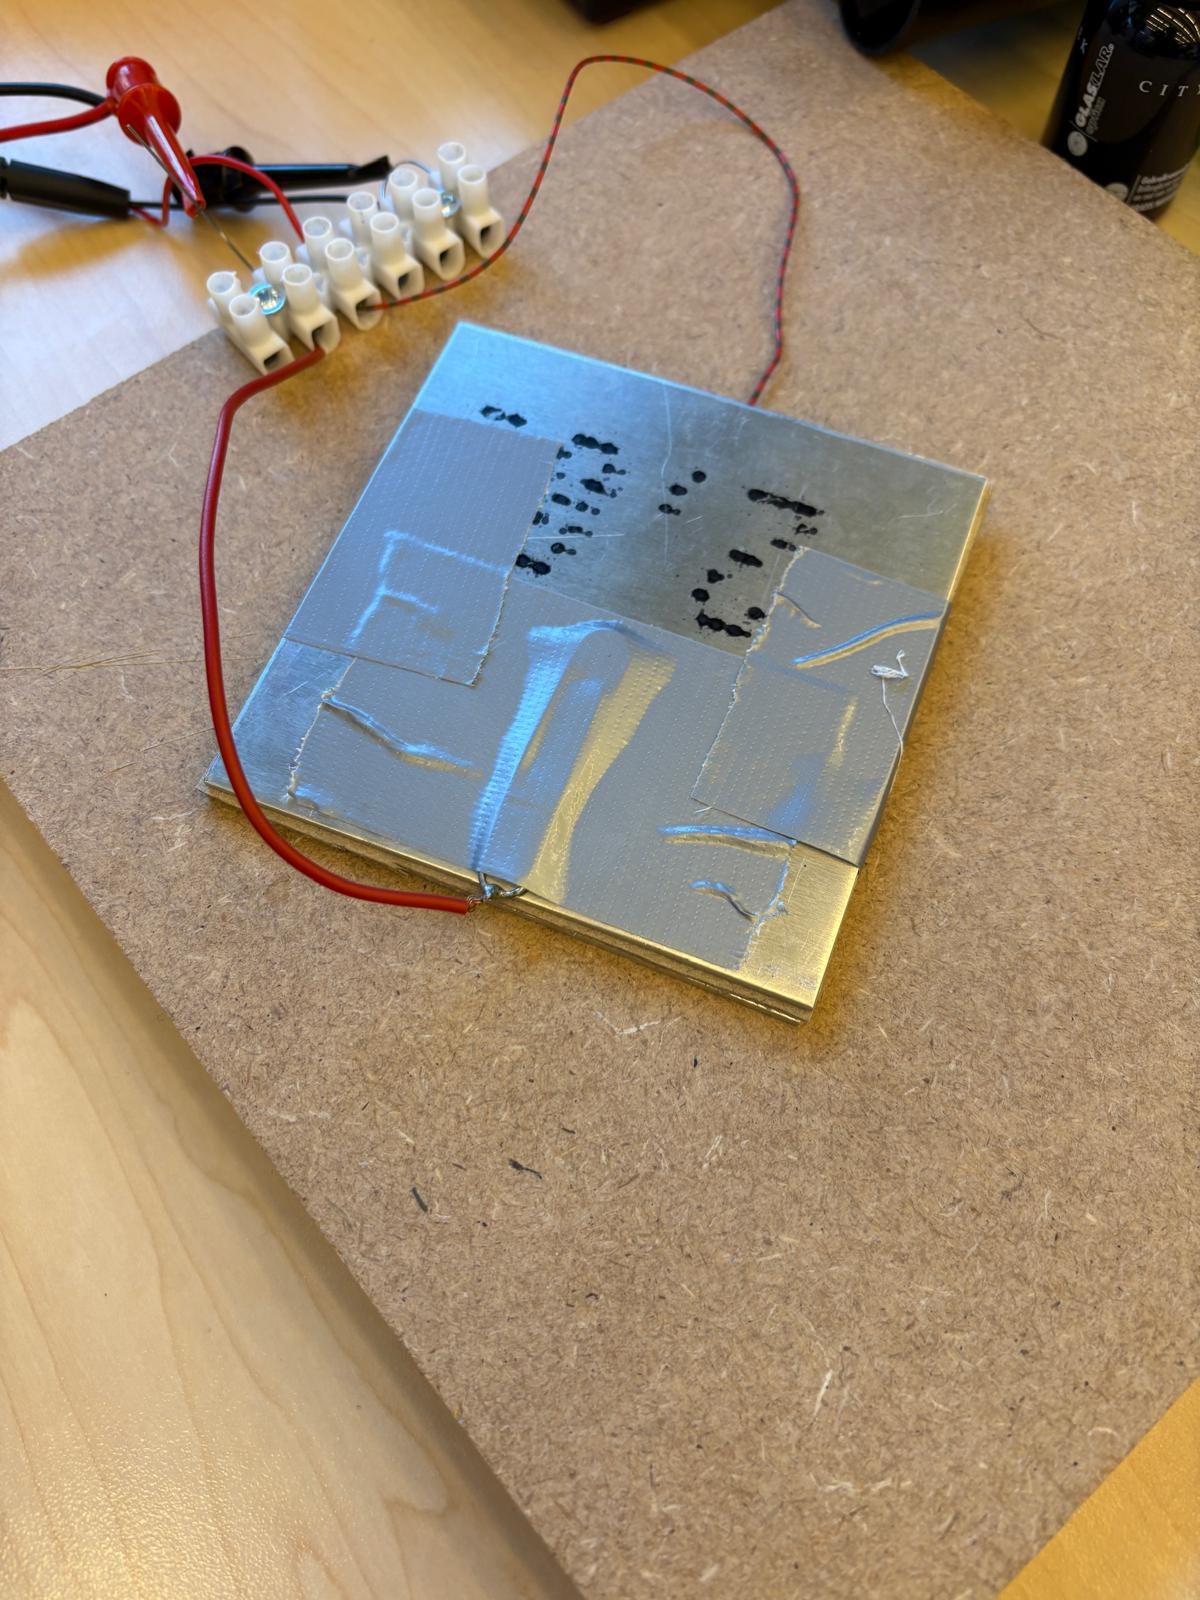

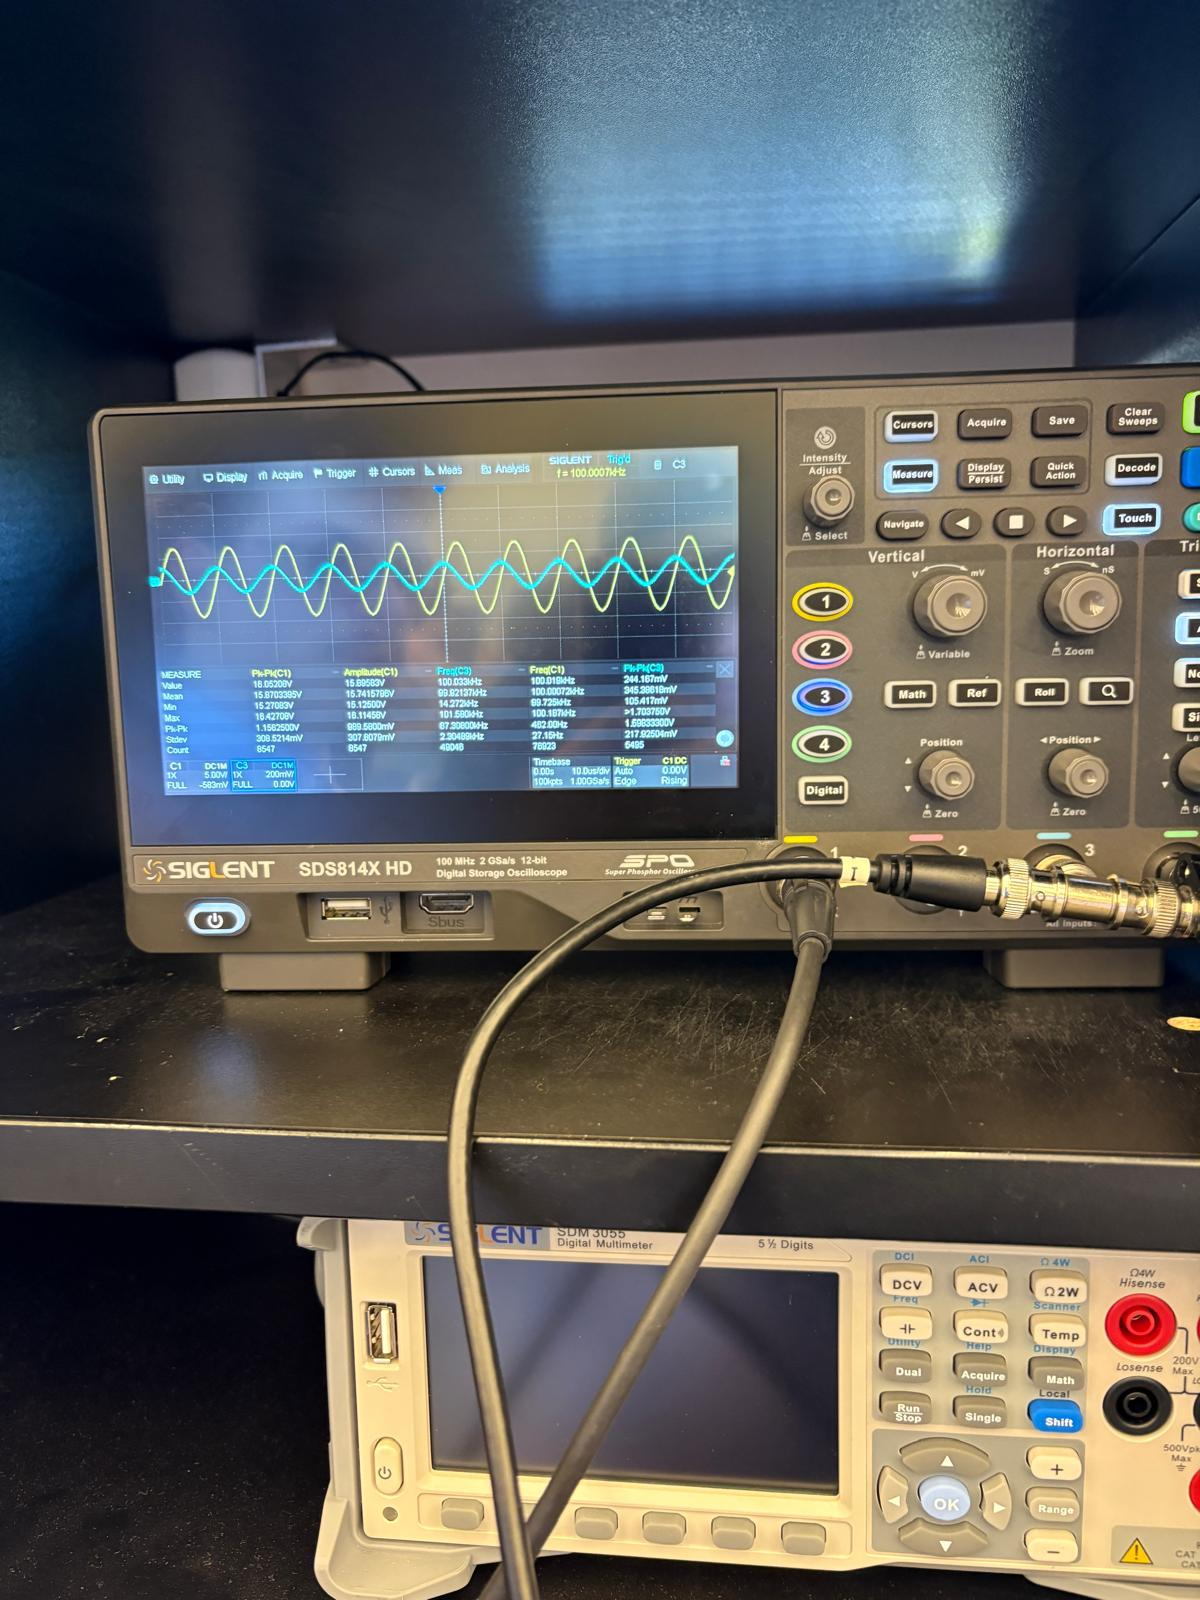

In [3]:
display(Image("foto_eerste.jpeg"))
display(Image("osci.jpeg"))

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 29| 147pF |0.74V | 0.8V | 159pF|

## *Opdracht 2:* Synthese.

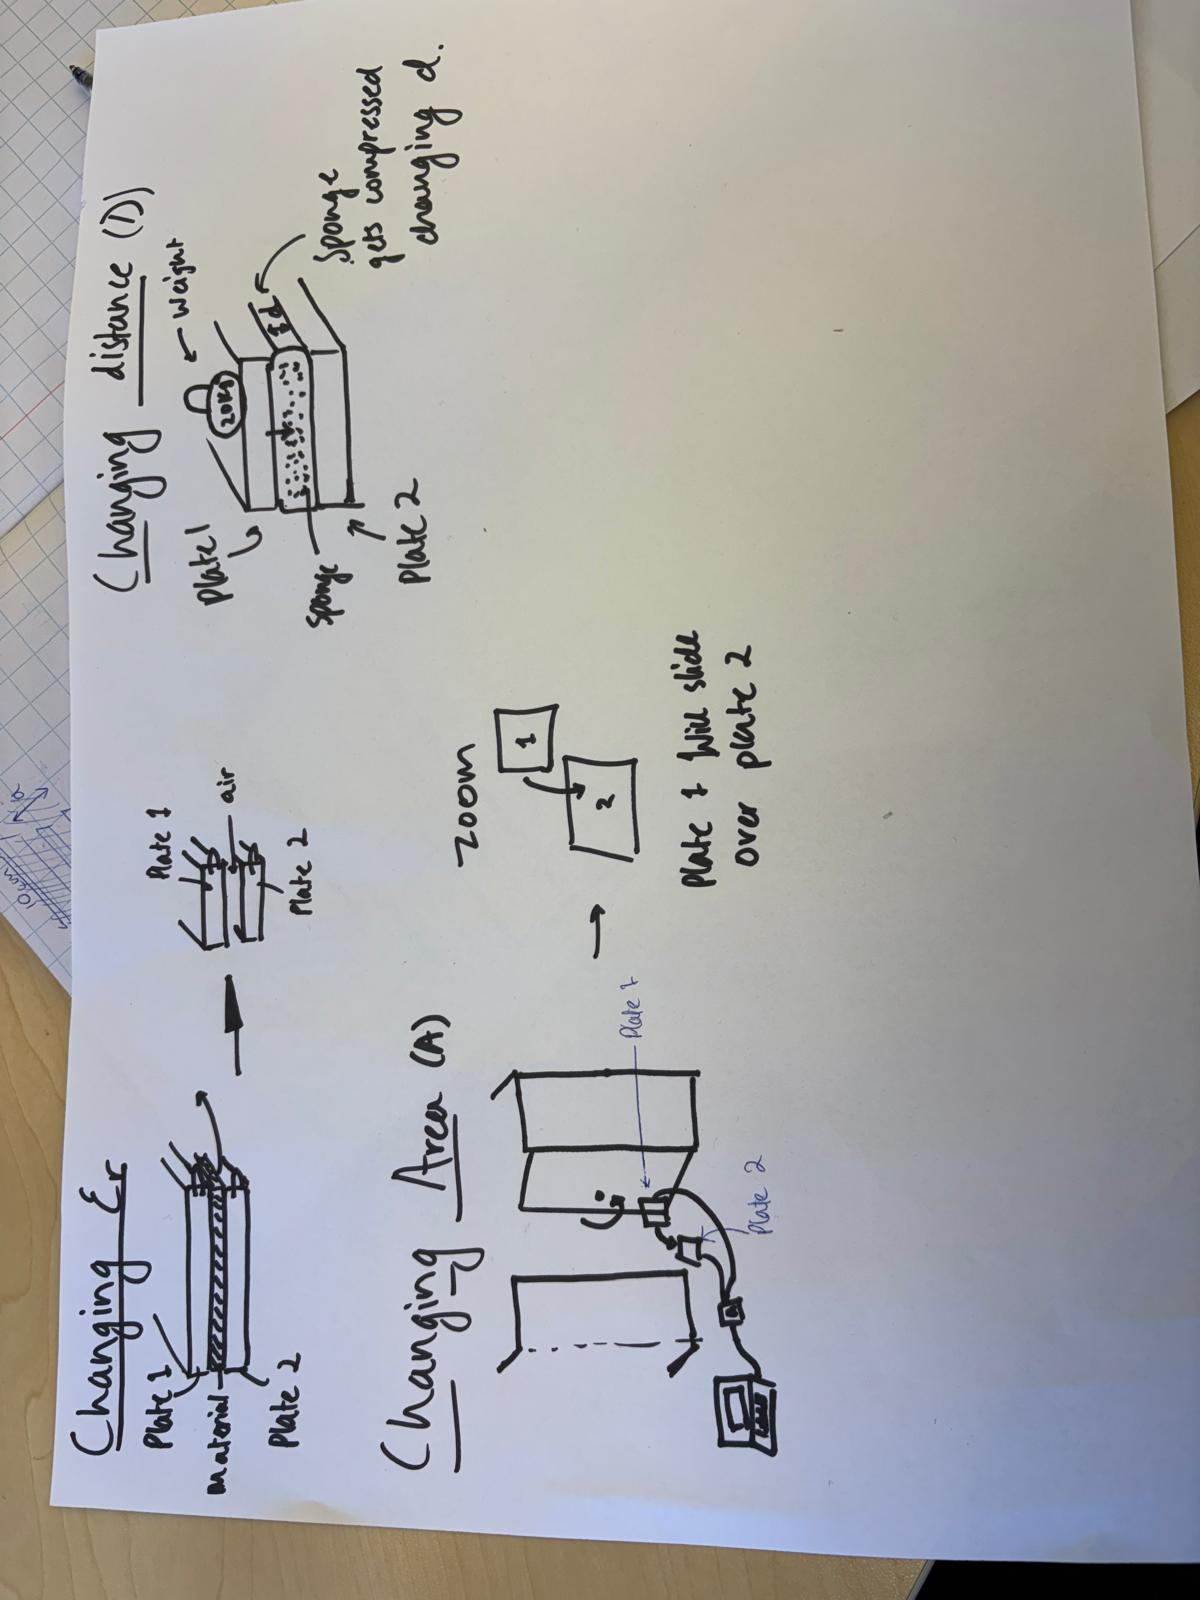

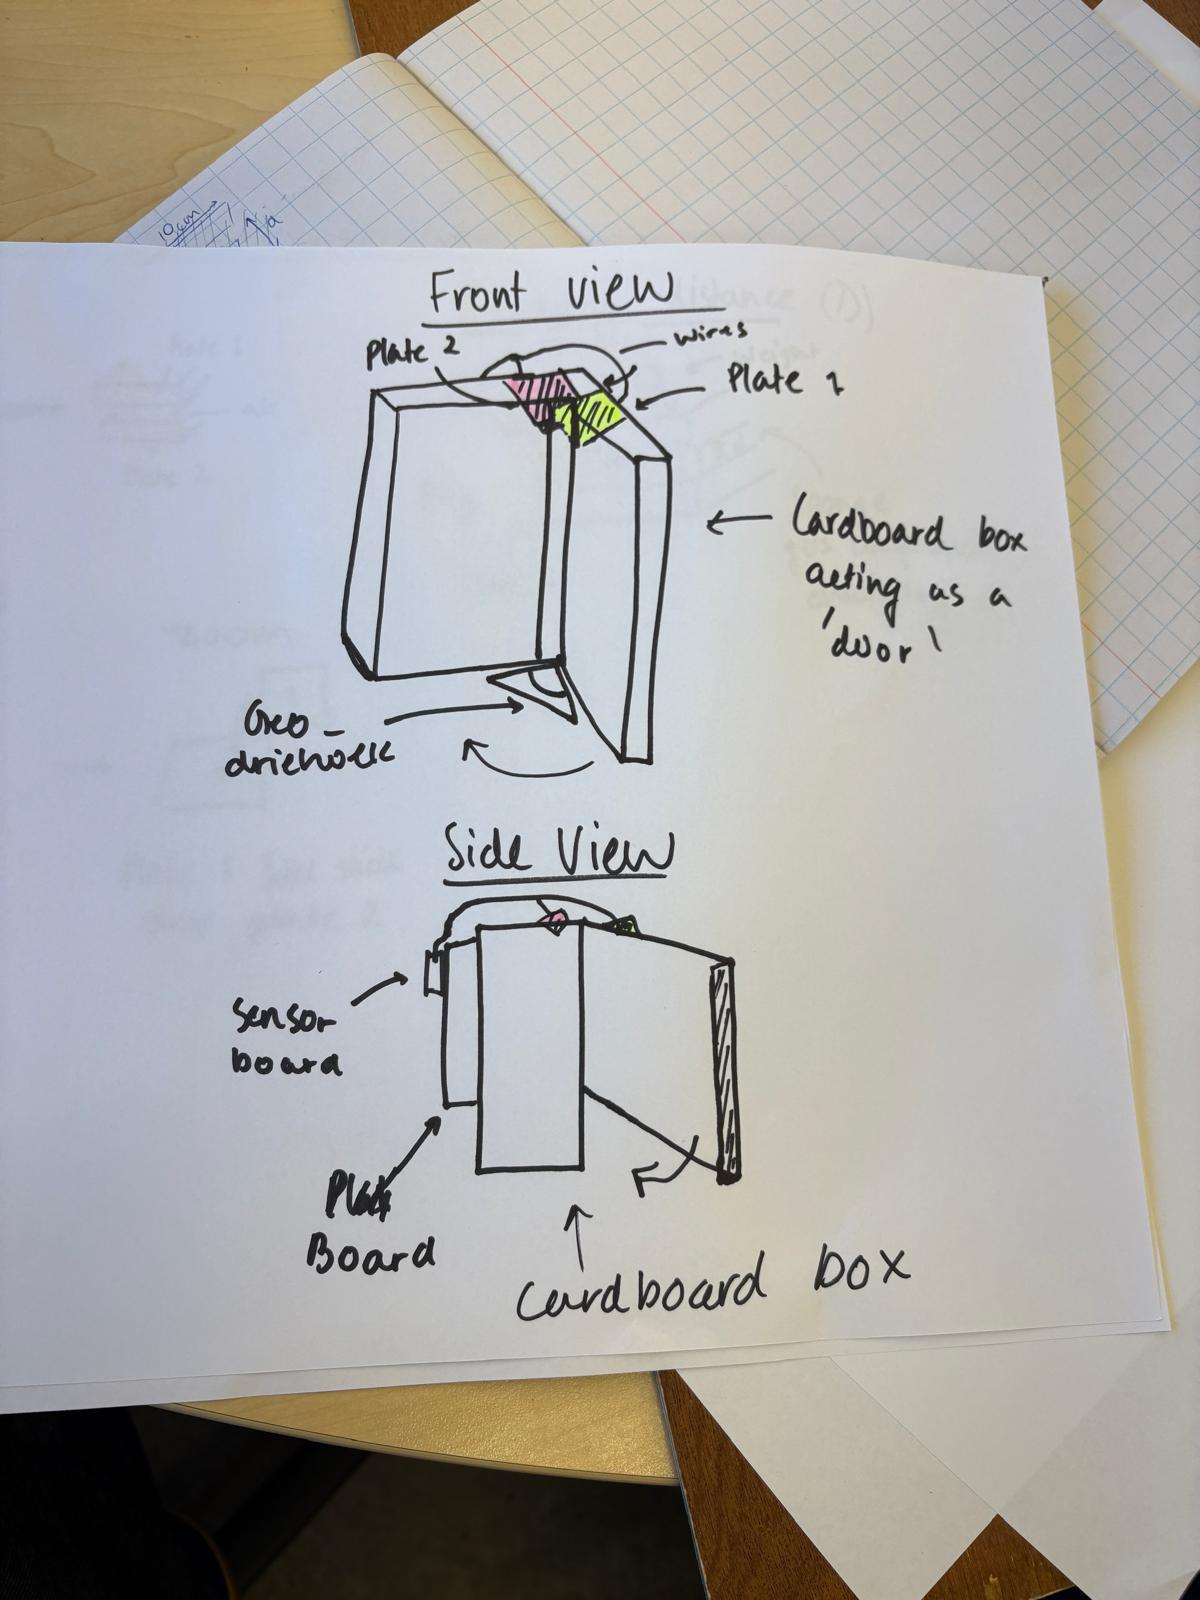

In [4]:
display(Image("schetsen.jpeg"))
display(Image("tekening_opstelling.jpeg"))


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die meet hoe ver een deur geopend is (hoeveel graden).

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

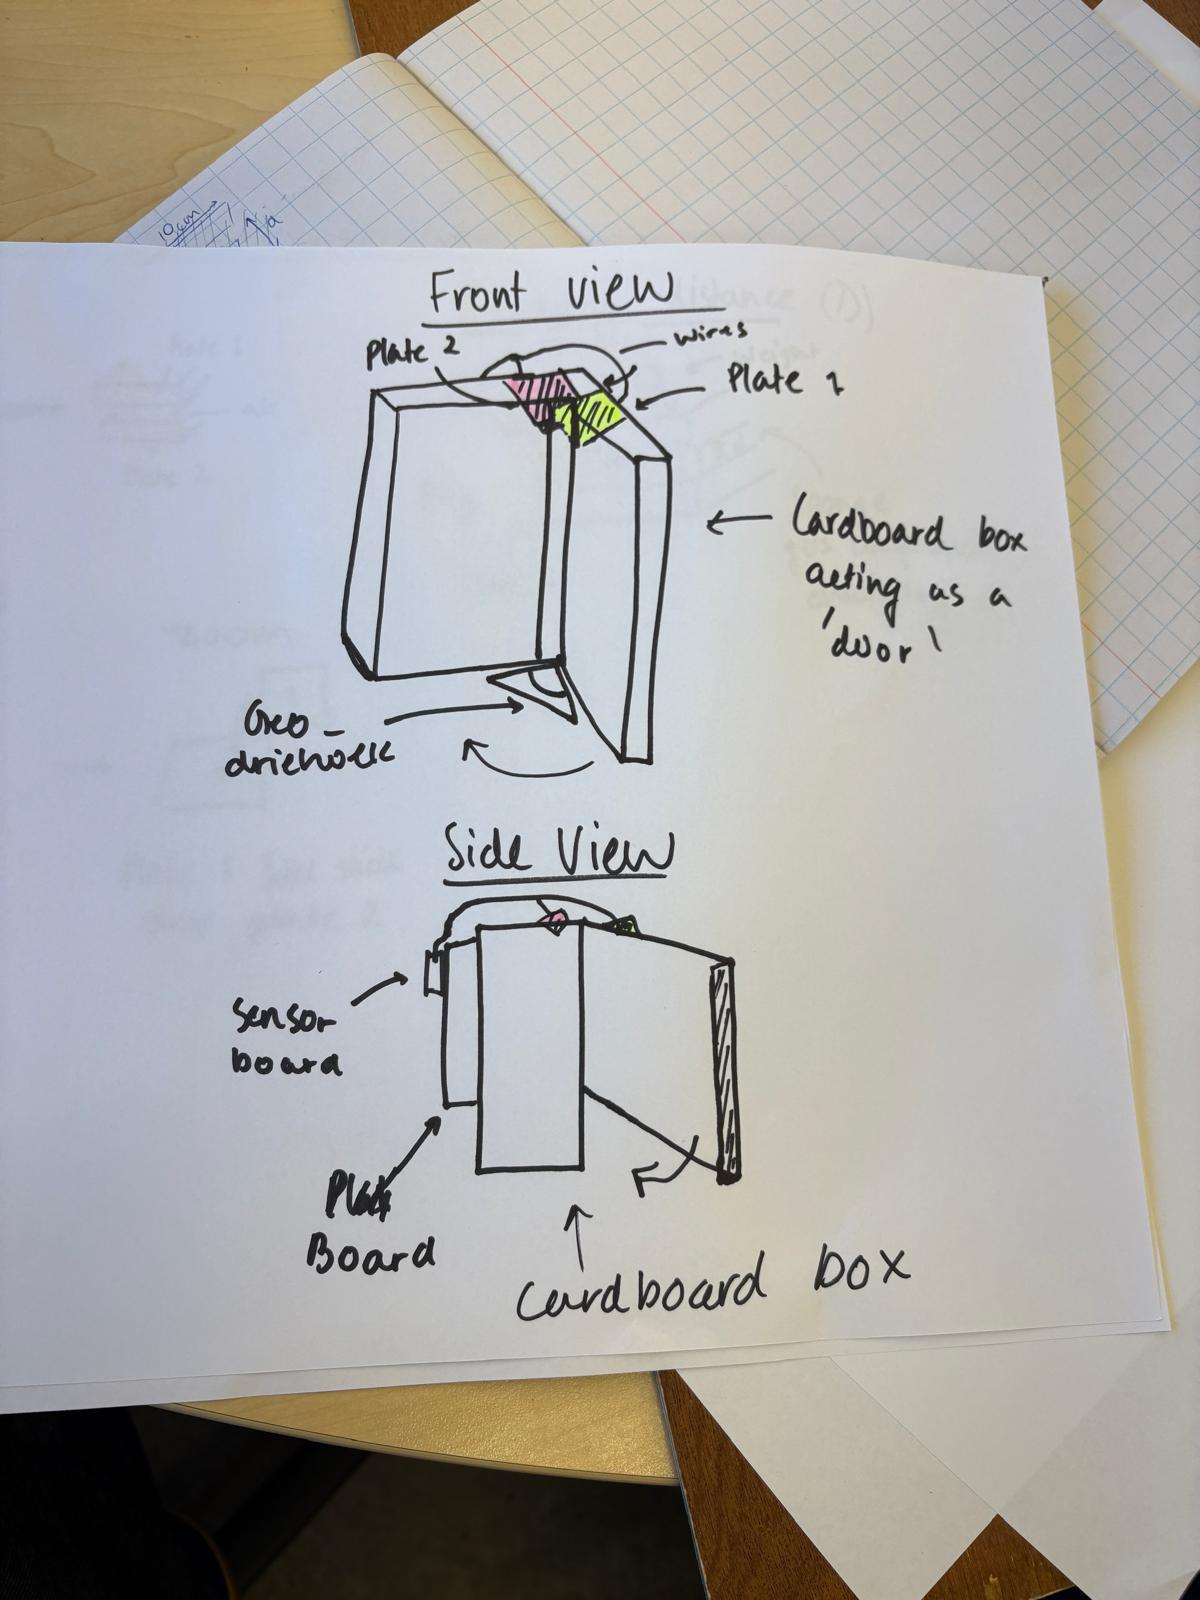

In [5]:
display(Image("tekening_opstelling.jpeg"))

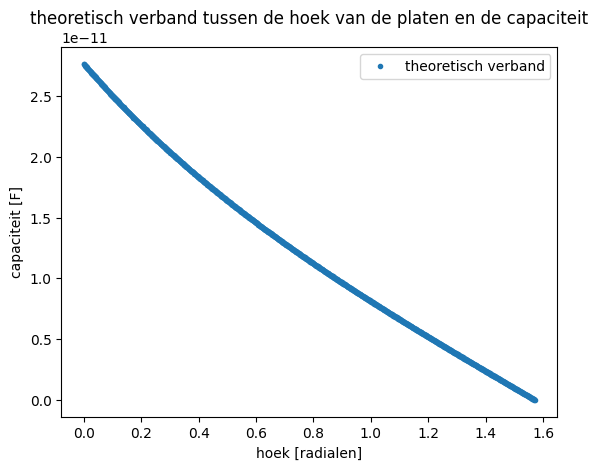

In [6]:
def opp(x):
    c=np.cos(x)*10
    e=np.sin(x)*10
    a=10-c
    d=10-e   
    b= d*np.tan(x)
    return 100-0.5*c*e-b*d*0.5-a*10
def vlakkeplaat(oppervlakte,spacing,epsilon_r): #2.
   
    return epsilon0*epsilon_r*oppervlakte/spacing
x_test = np.linspace(0,0.5*np.pi,1000)
oppervlak = opp(x_test)/10000
plt.plot(x_test,(vlakkeplaat(oppervlak,0.8e-2,2.5)),'.',label="theoretisch verband")
plt.xlabel("hoek [radialen]")
plt.ylabel("capaciteit [F]")
plt.title("theoretisch verband tussen de hoek van de platen en de capaciteit")
plt.legend()
plt.show()

In [7]:
capaicteit_min = capacitance(0.1,1000,8,100000)
capaicteit_gem = capacitance(0.280,1000,8,100000)
capaicteit_max = capacitance(0.245,1000,8,100000)
print(capaicteit_min,capaicteit_gem,capaicteit_max)

1.9894367886486922e-11 5.570423008216338e-11 4.8741201321892954e-11


## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 20 |131.15 |
| gemiddelde capaciteit| 56 |281.15 |
| maximale capaciteit| 91 |458.01 |

## Opdracht 6: Foto's werkende opstelling.

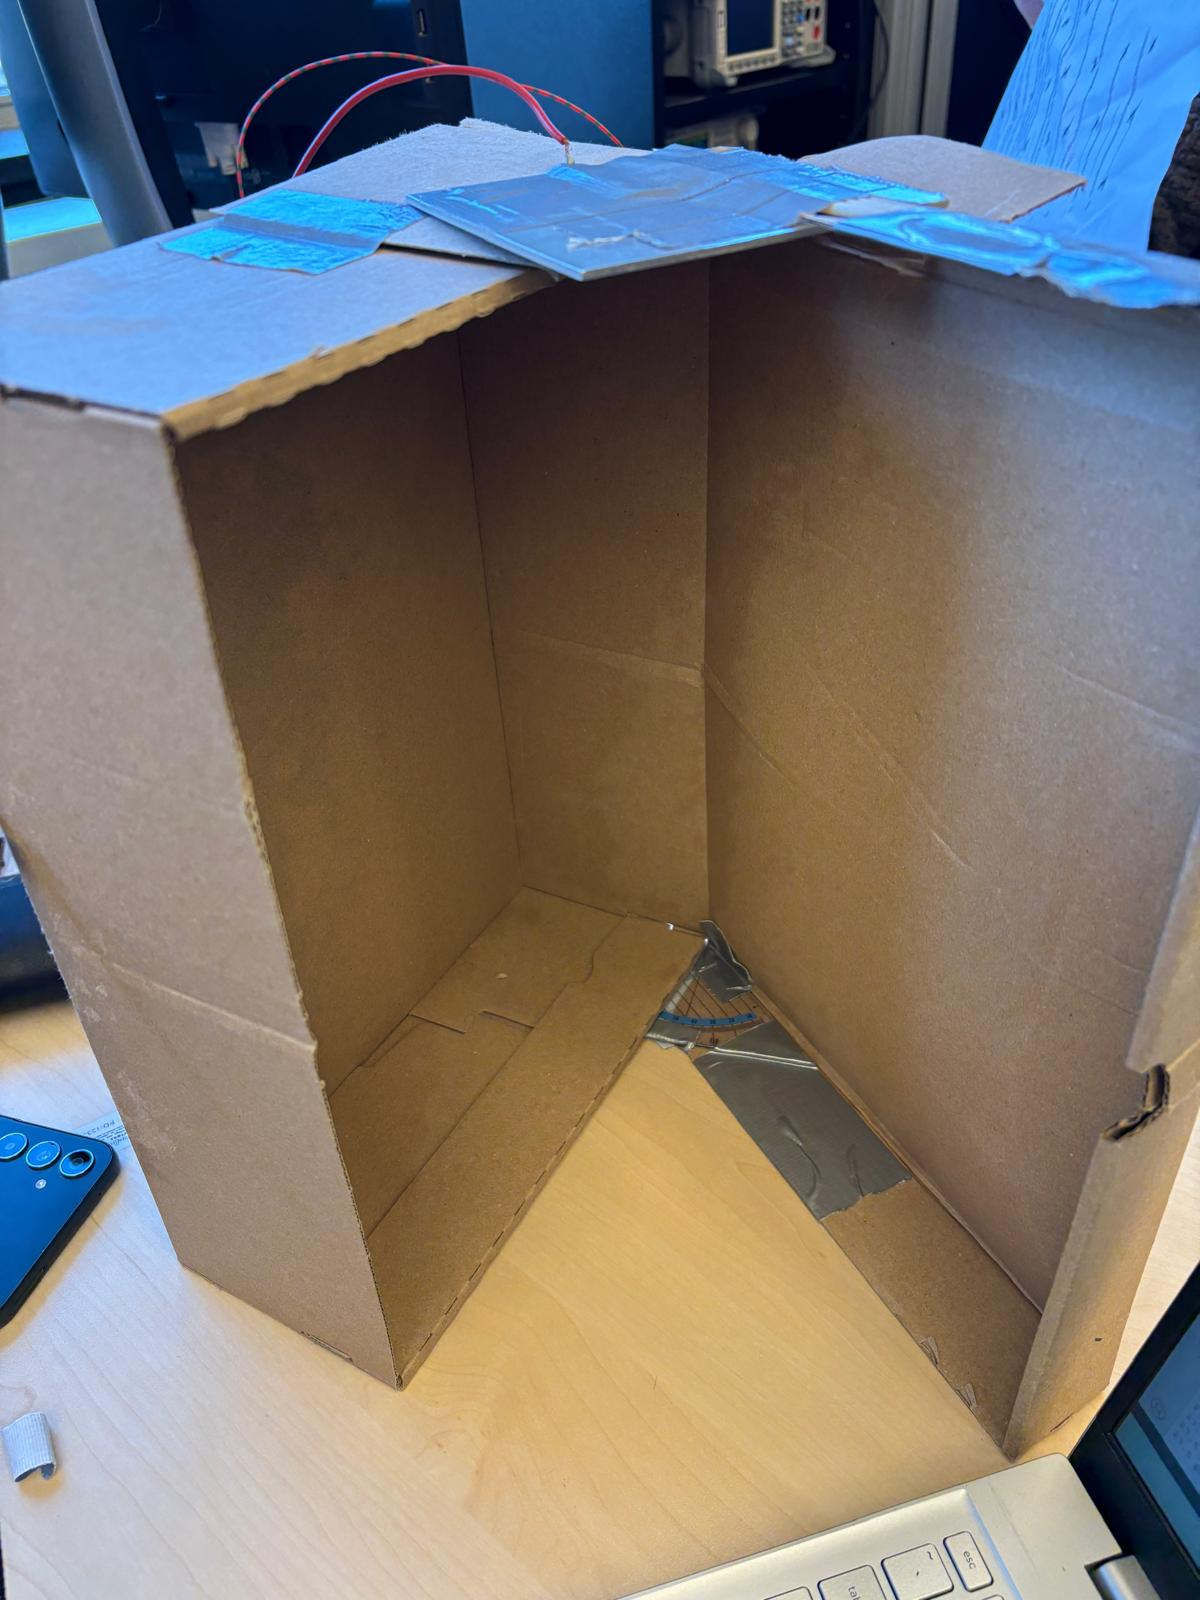

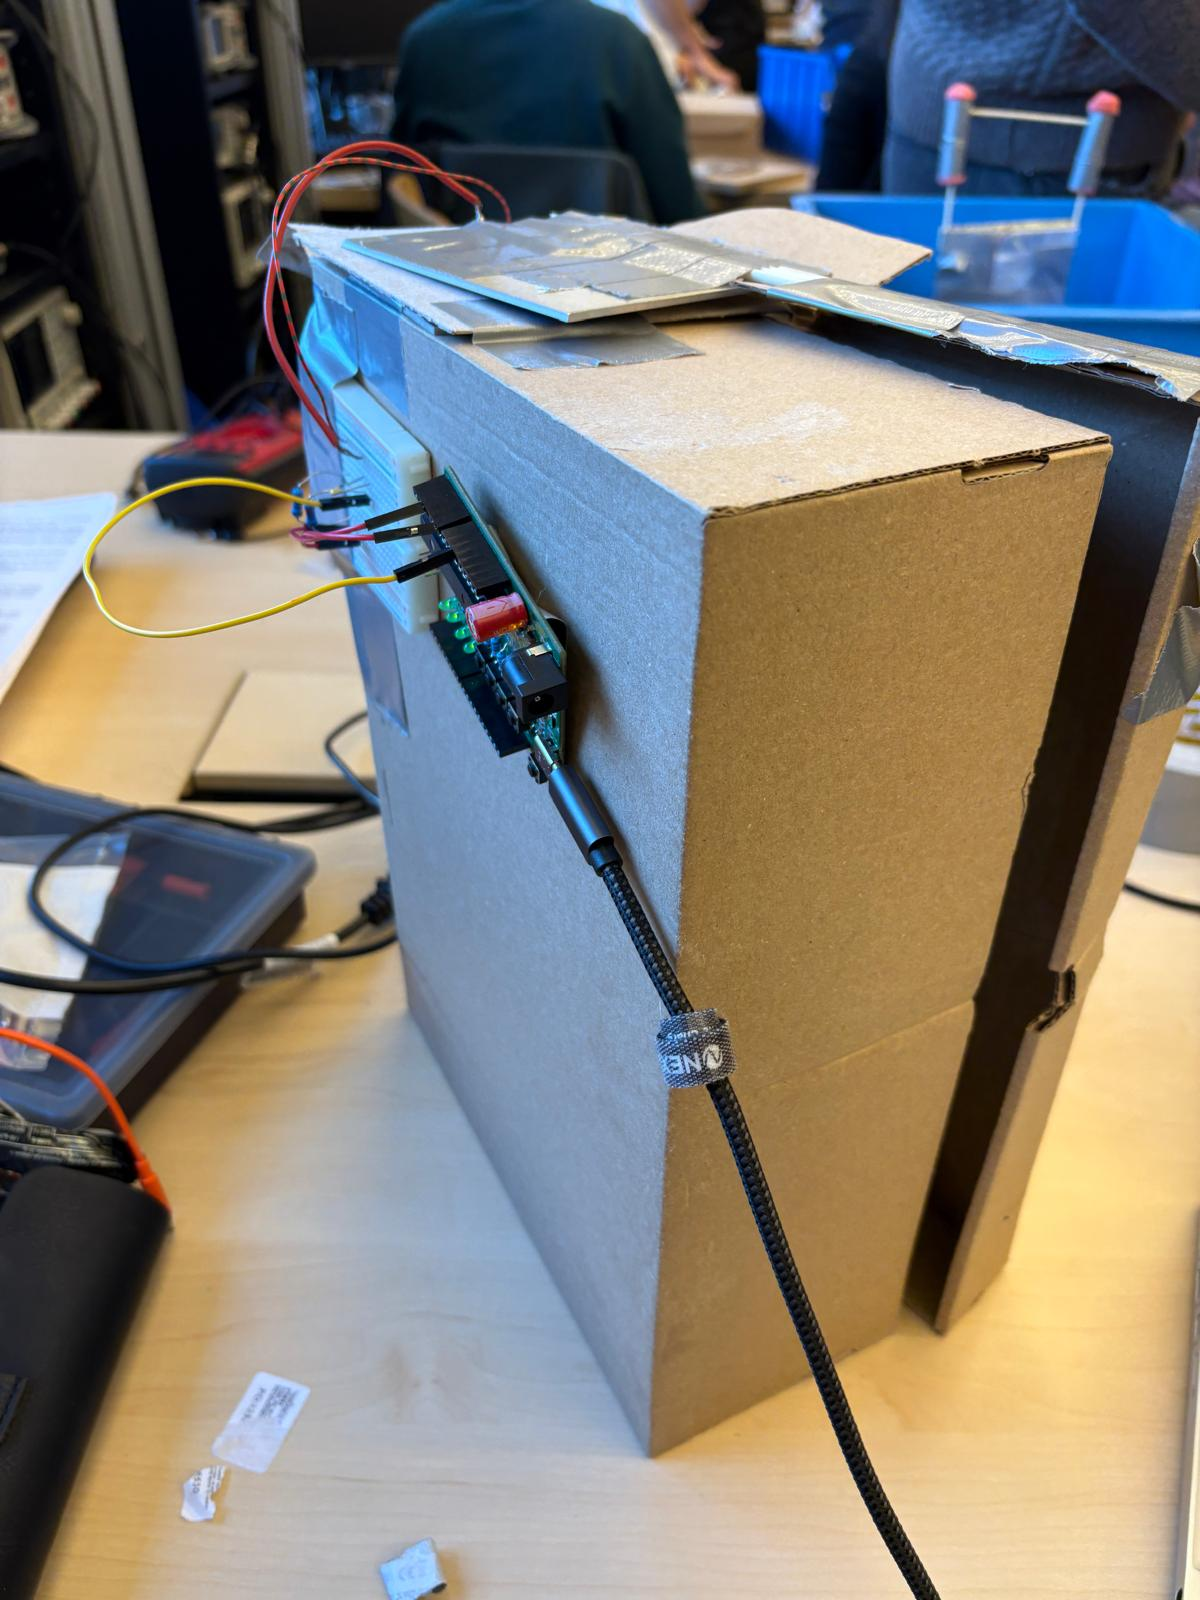

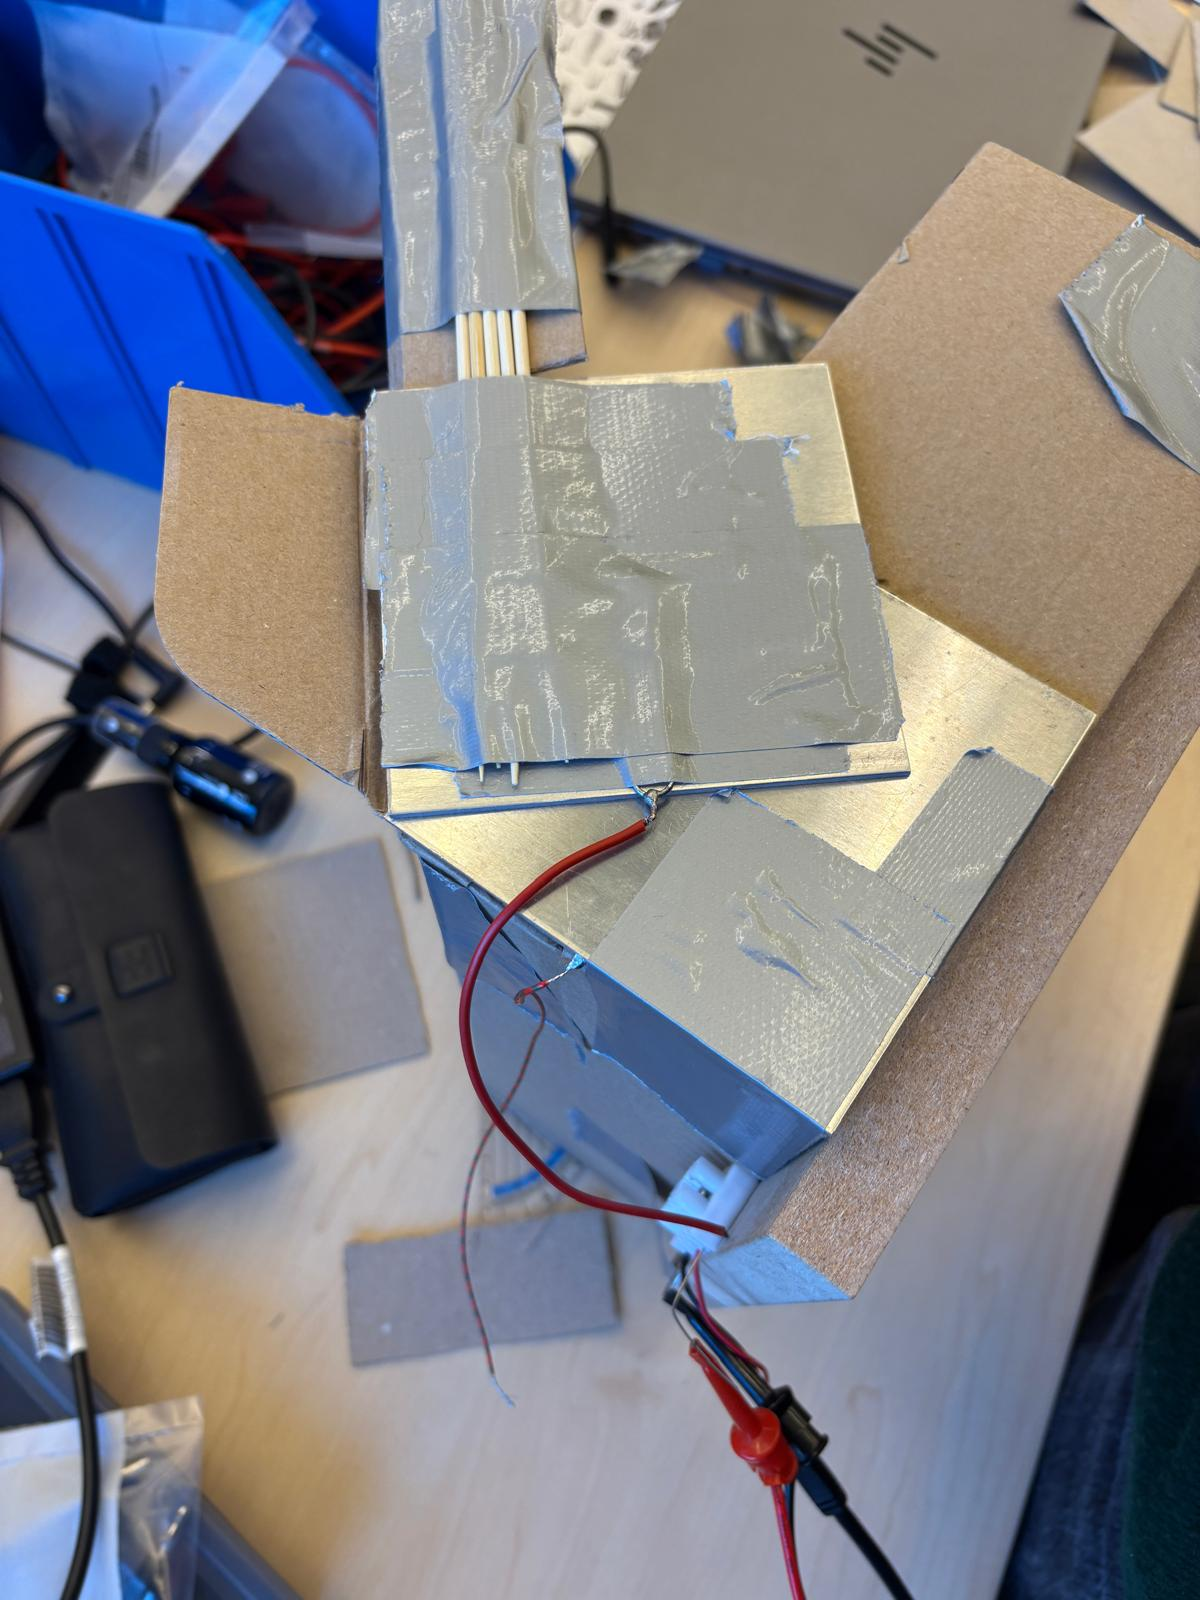

In [8]:
display(Image("opstelling1.jpeg"))
display(Image("opstelling2.jpeg"))
display(Image("opstelling3.jpeg"))

## Opdracht 7: Plot de kalibratiegrafiek.

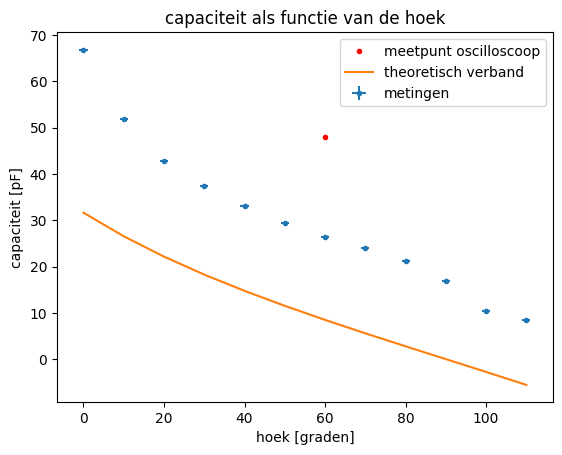

In [9]:

graden = np.array([0,10,20,30,40,50,60,70,80,90,100,110])
radialen = graden/180*np.pi
Farad = np.array([66.8,51.8,42.8,37.3,33,29.5,26.3,23.9,21.2,16.8,10.3,8.5])

plt.errorbar(graden,Farad,0.2,1,'.',label="metingen")
osci = 48
def opp(x):
    c=np.cos(x)*10
    e=np.sin(x)*10
    a=10-c
    d=10-e   
    b= d*np.tan(x)
    return 100-0.5*c*e-b*d*0.5-a*10
opps = opp(radialen)/10000
def vlakkeplaat(oppervlakte,spacing,epsilon_r): #2.
   
    return epsilon0*epsilon_r*oppervlakte/spacing

x_test = np.linspace(0,110,1000)
plt.plot(60,osci,'r.',label='meetpunt oscilloscoop')
plt.plot(graden,(vlakkeplaat(opps,0.7e-2,2.5)/1e-12),label="theoretisch verband")
plt.xlabel('hoek [graden]')
plt.ylabel('capaciteit [pF]')
plt.title("capaciteit als functie van de hoek")
plt.legend()
plt.show()


## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* De overlap door de hoek was niet altijd consistent. Het gebruik van een echte deur, zou de pivot punt constant houden, en dat zou voor een betere relatie tussen the overlap door de hoek en capacitance zorgen. 
* Tijdens het meten waren en nog altijd best veel trillingen in het data omdat de karton doos zoms omhoog geen tijdens het roteren en dat zorgde over voor sommige inconsistenties waardoor wij niet te veel meetpunten konden halen. Het zou handiger zijn om stevigere material te gebruiken. 

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](tudelftLogo.png)

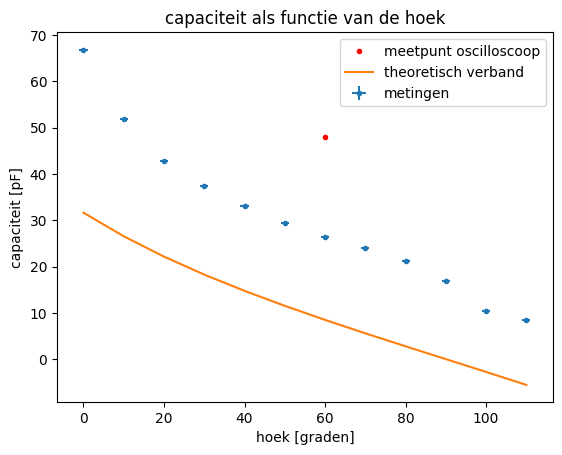

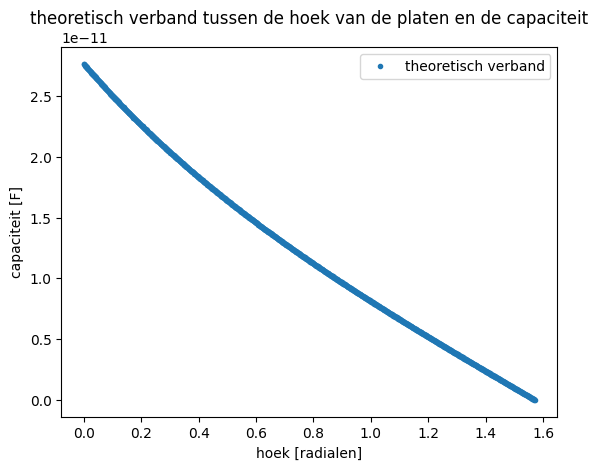

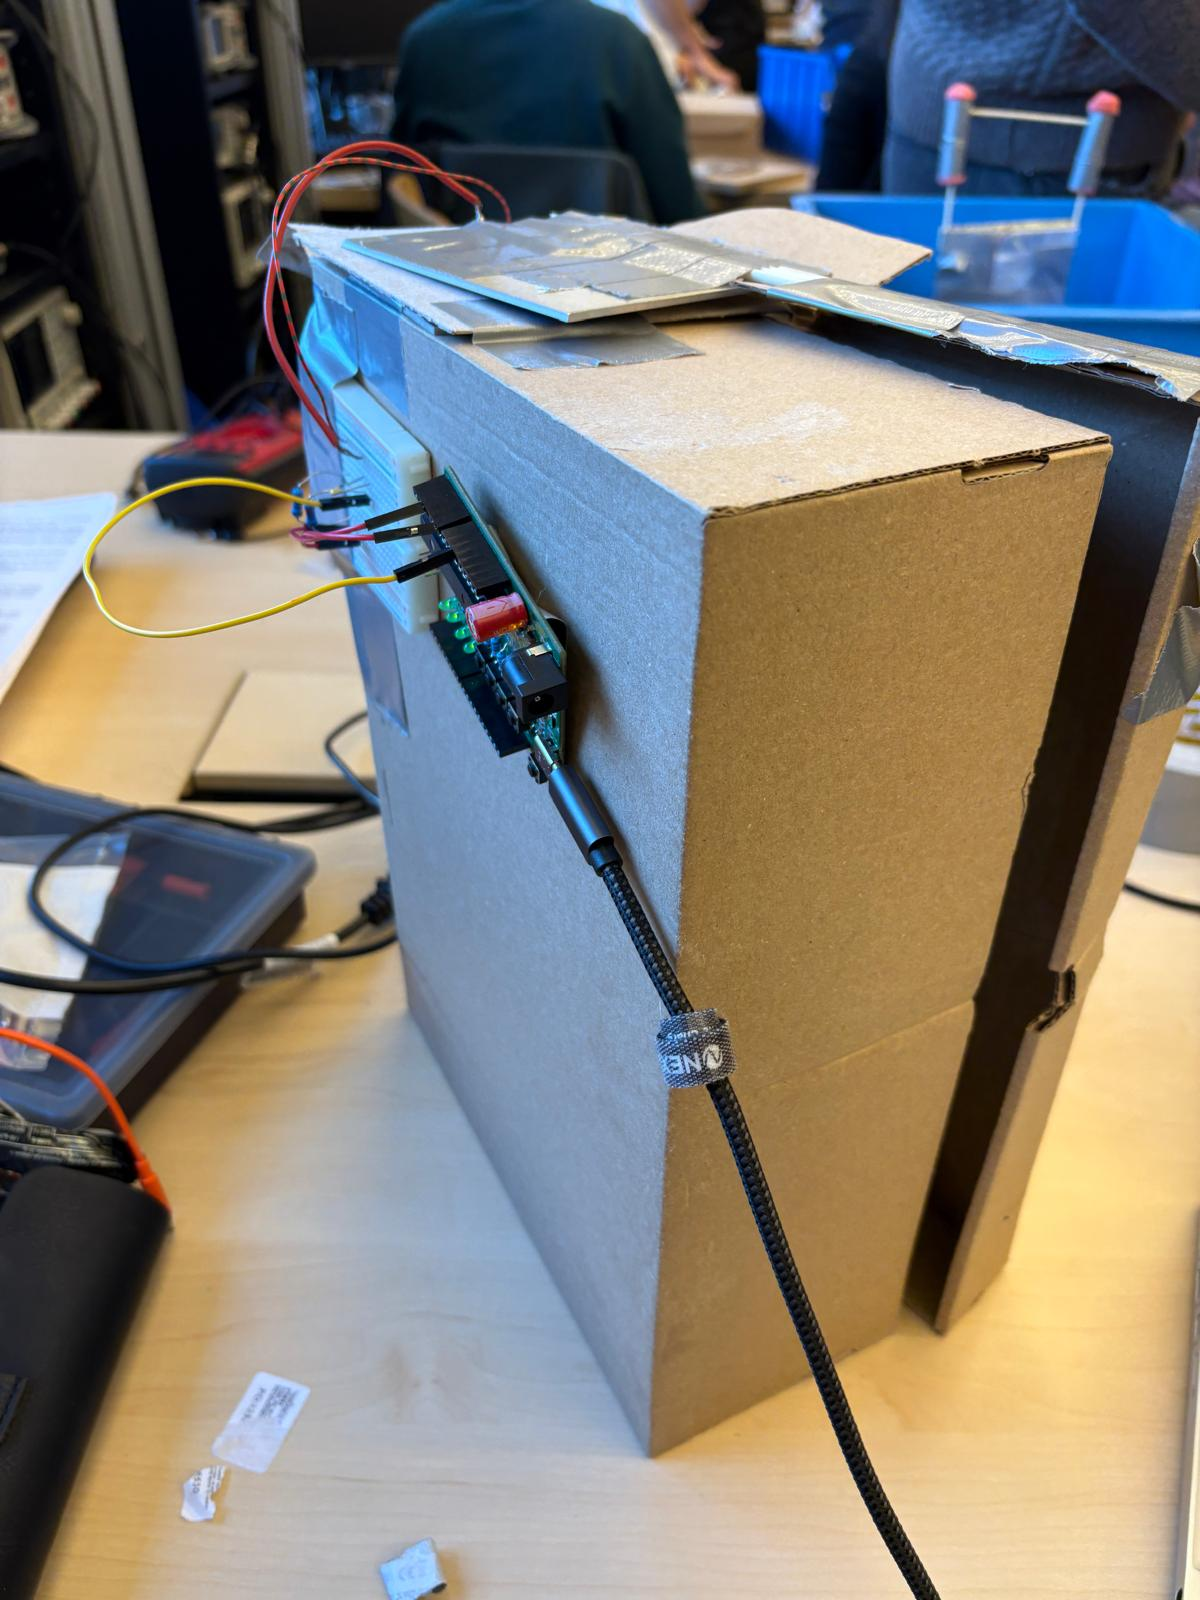

In [10]:

graden = np.array([0,10,20,30,40,50,60,70,80,90,100,110])
radialen = graden/180*np.pi
Farad = np.array([66.8,51.8,42.8,37.3,33,29.5,26.3,23.9,21.2,16.8,10.3,8.5])

plt.errorbar(graden,Farad,0.2,1,'.',label="metingen")
osci = 48
def opp(x):
    c=np.cos(x)*10
    e=np.sin(x)*10
    a=10-c
    d=10-e   
    b= d*np.tan(x)
    return 100-0.5*c*e-b*d*0.5-a*10
opps = opp(radialen)/10000
def vlakkeplaat(oppervlakte,spacing,epsilon_r): #2.
   
    return epsilon0*epsilon_r*oppervlakte/spacing

x_test = np.linspace(0,110,1000)
plt.plot(60,osci,'r.',label='meetpunt oscilloscoop')
plt.plot(graden,(vlakkeplaat(opps,0.7e-2,2.5)/1e-12),label="theoretisch verband")
plt.xlabel('hoek [graden]')
plt.ylabel('capaciteit [pF]')
plt.title("capaciteit als functie van de hoek")
plt.legend()
plt.show()
def opp(x):
    c=np.cos(x)*10
    e=np.sin(x)*10
    a=10-c
    d=10-e   
    b= d*np.tan(x)
    return 100-0.5*c*e-b*d*0.5-a*10
def vlakkeplaat(oppervlakte,spacing,epsilon_r): #2.
   
    return epsilon0*epsilon_r*oppervlakte/spacing
x_test = np.linspace(0,0.5*np.pi,1000)
oppervlak = opp(x_test)/10000
plt.plot(x_test,(vlakkeplaat(oppervlak,0.8e-2,2.5)),'.',label="theoretisch verband")
plt.xlabel("hoek [radialen]")
plt.ylabel("capaciteit [F]")
plt.title("theoretisch verband tussen de hoek van de platen en de capaciteit")
plt.legend()
plt.show()
display(Image("opstelling2.jpeg"))


## Opdracht 10: Vul hieronder de conclusie in.

In conclusie, hadden wij in het theoretische model in opdracht 4 gemaakt om te vergelijken met de fysieke resultaat. Uiteidelijk met gebruik van deze theoretische model hebben wij de zelfde curve fit in onze echte data gebruikt. Qua data zichzelf bij het meten met het arduino waren er duidelijke mooie trends. Elke keer dat de doos 10 graden verder werdt geschoven gaf de arduino een mooie dalende curve die de actie van de deur bijna na deed. Uit eindelijk was er een stevige concreet relatie tussen de hoek (graden) en capaciteit (picoFarad) (pF), de correlatie was negatief. Met toename in de hoek kregen wij een afname in de capaciteit. Het theoretische model heeft ook dezelfde vorm als een lijn door de gemeten punten. Echter blijkt de de voorspelde curve niet overeen te komen met onze gemeten punten, dit kan meerdere oorzaken hebben. Voor het theoretische model hebben is aaangenomen dat de scharnier niet beweegt, dit is echter wel zo als de doos geopend wordt. Daarnaast wordt er ook van uitgegaan dat het elektrische veld aan de rand van de platen stopt en dat er geen edge effecten zijn. Ook varieert de afstand tussen de platen wanneer de doos geopend wordt. Dit allemaal draagt eraan bij dat de curve weliswaar dezelfde vorm heeft als de gemeten punten, maar niet op dezelfde plek is.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

## Leerdoel 1

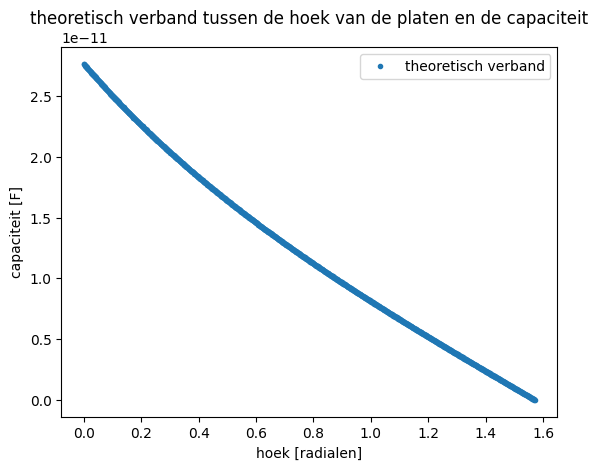

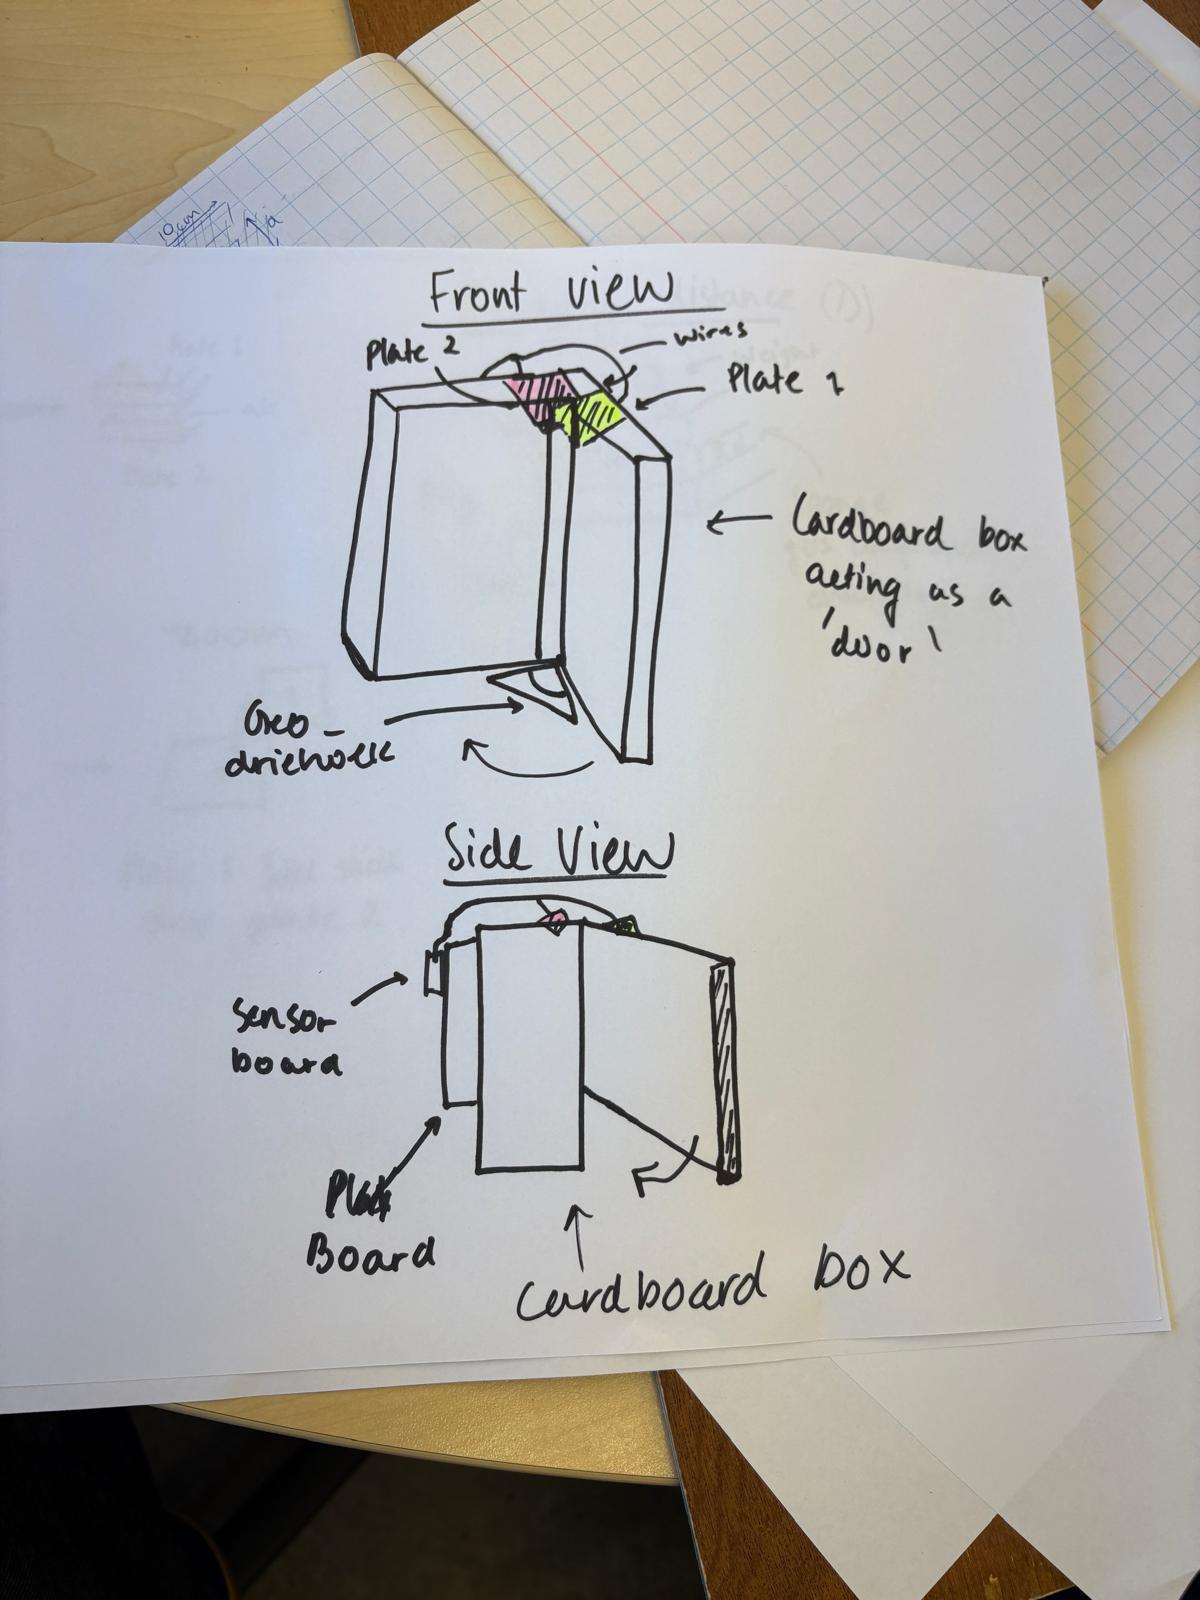

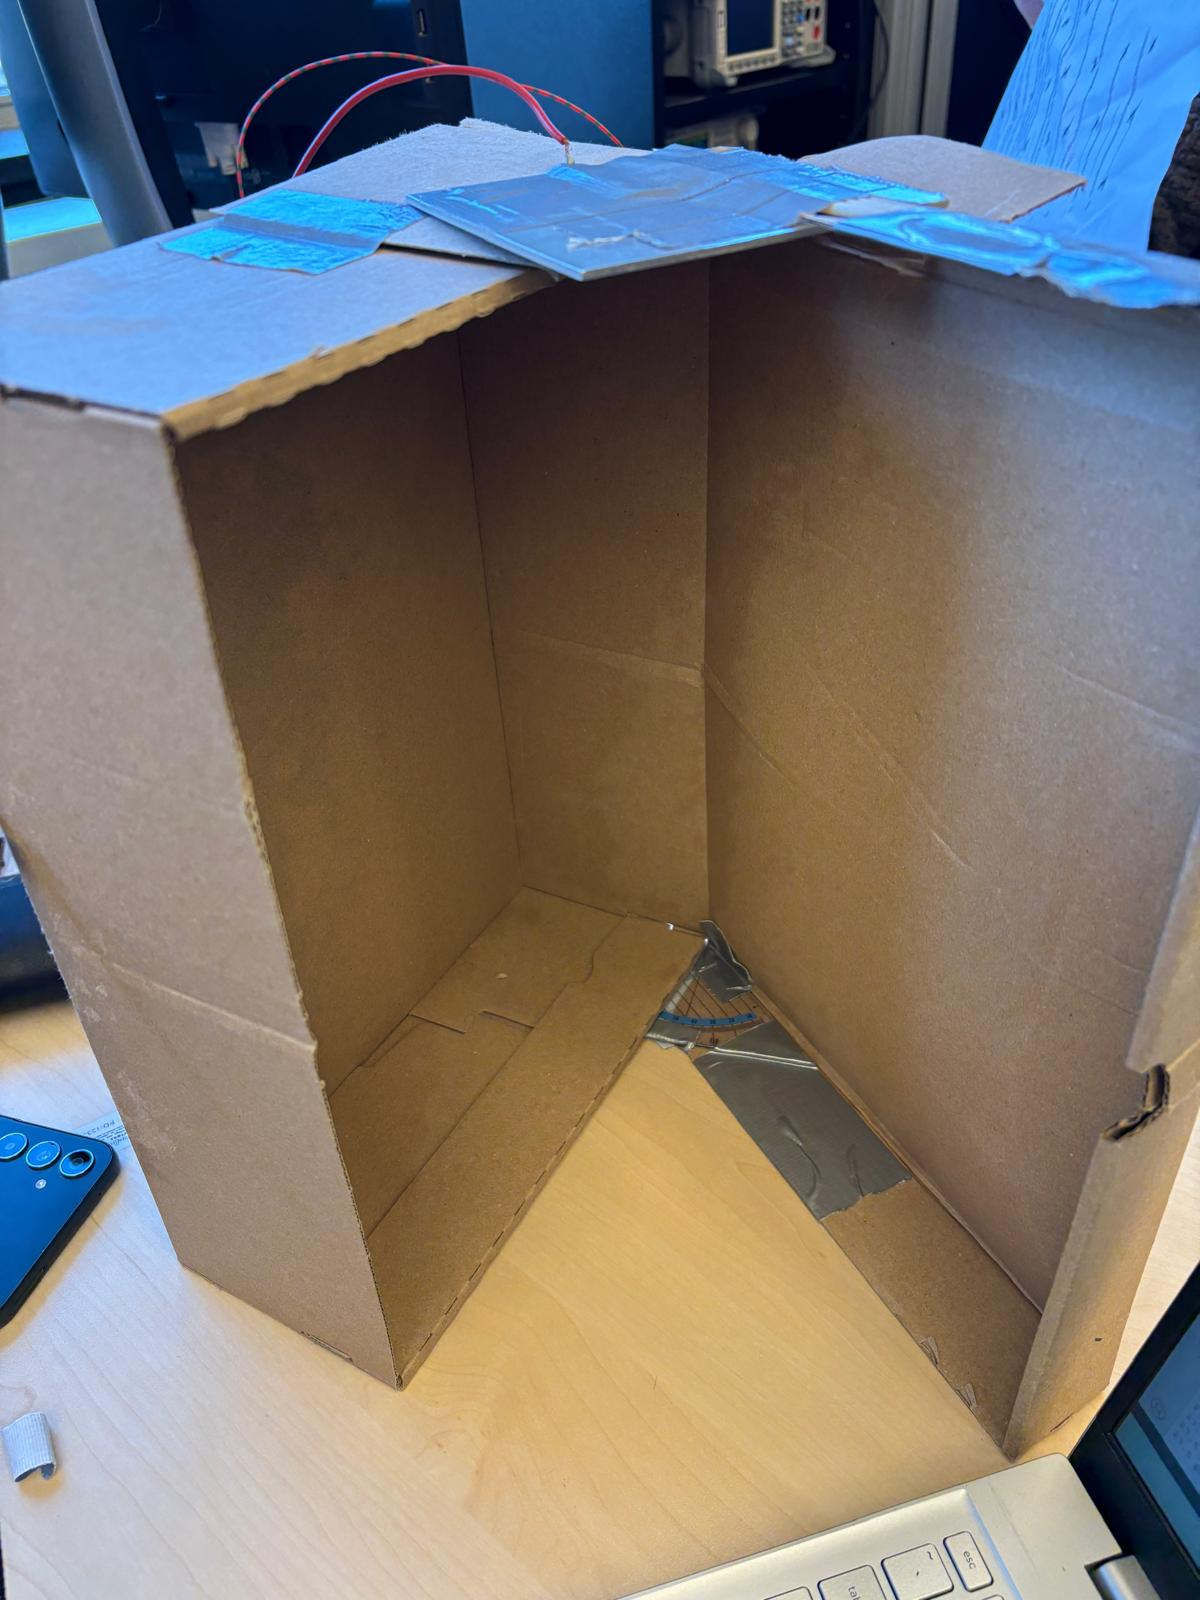

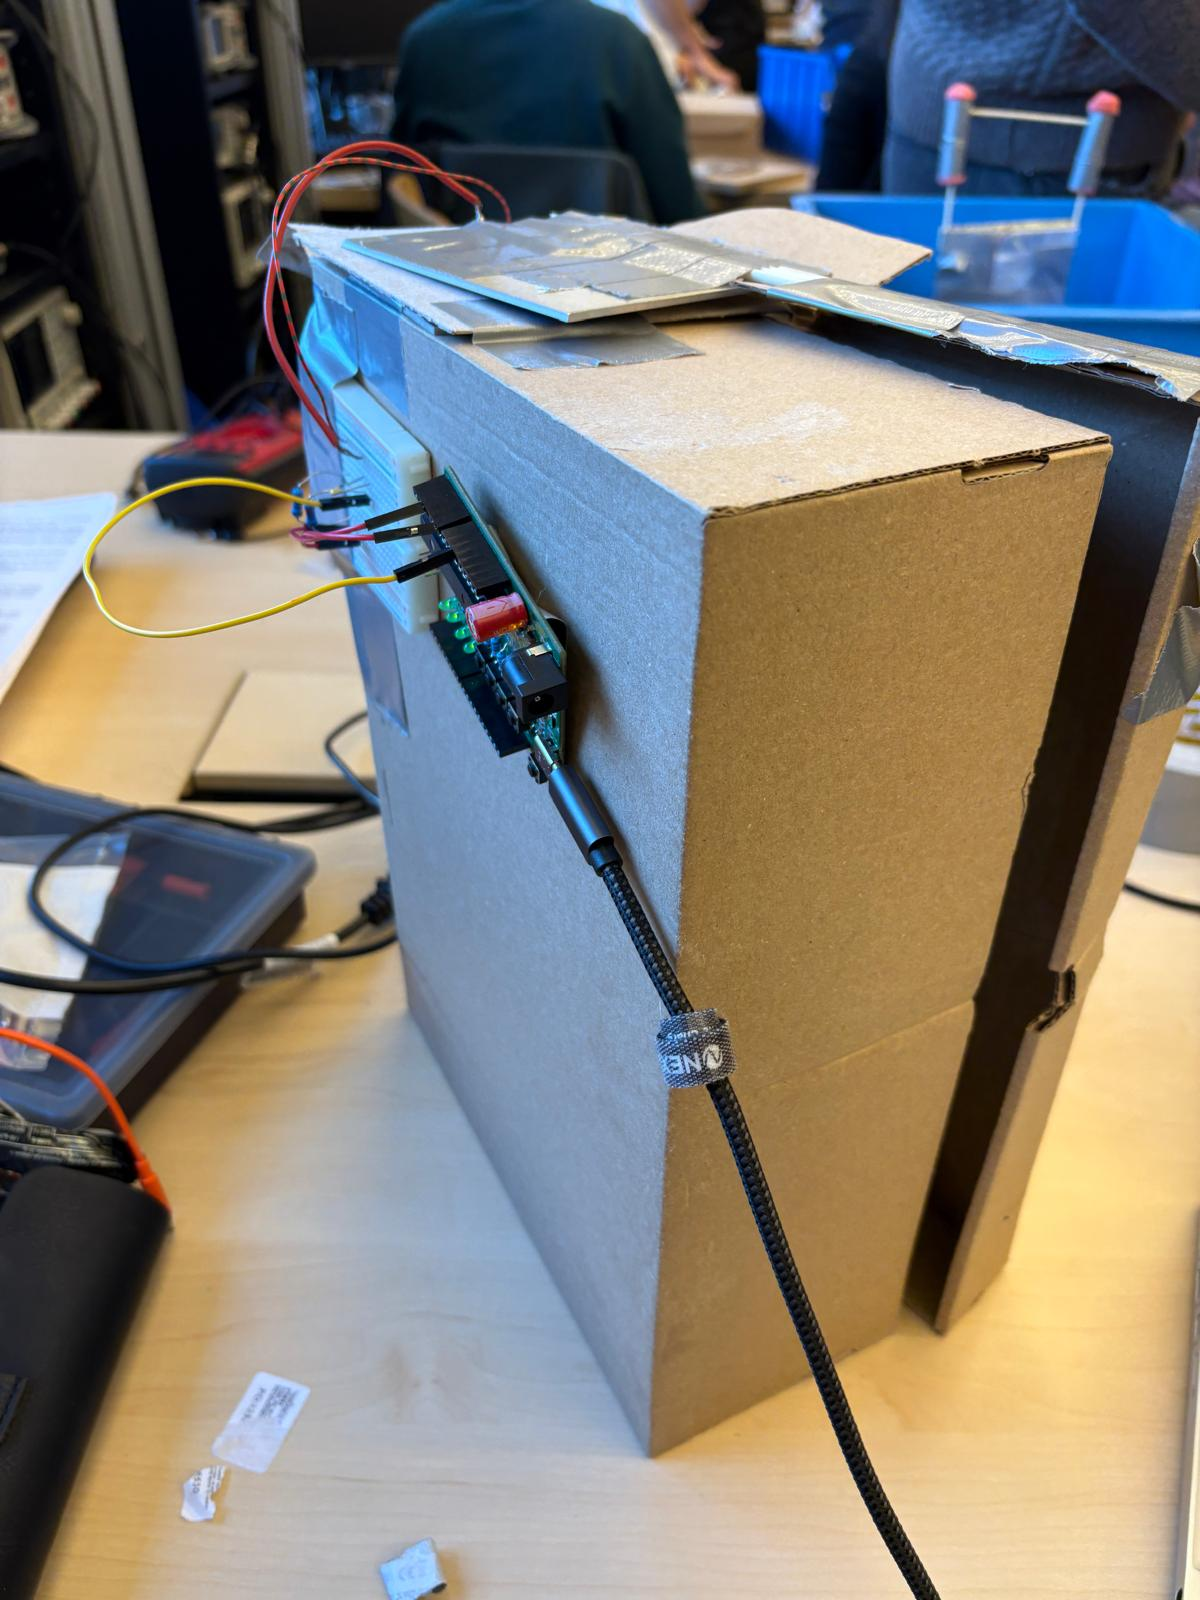

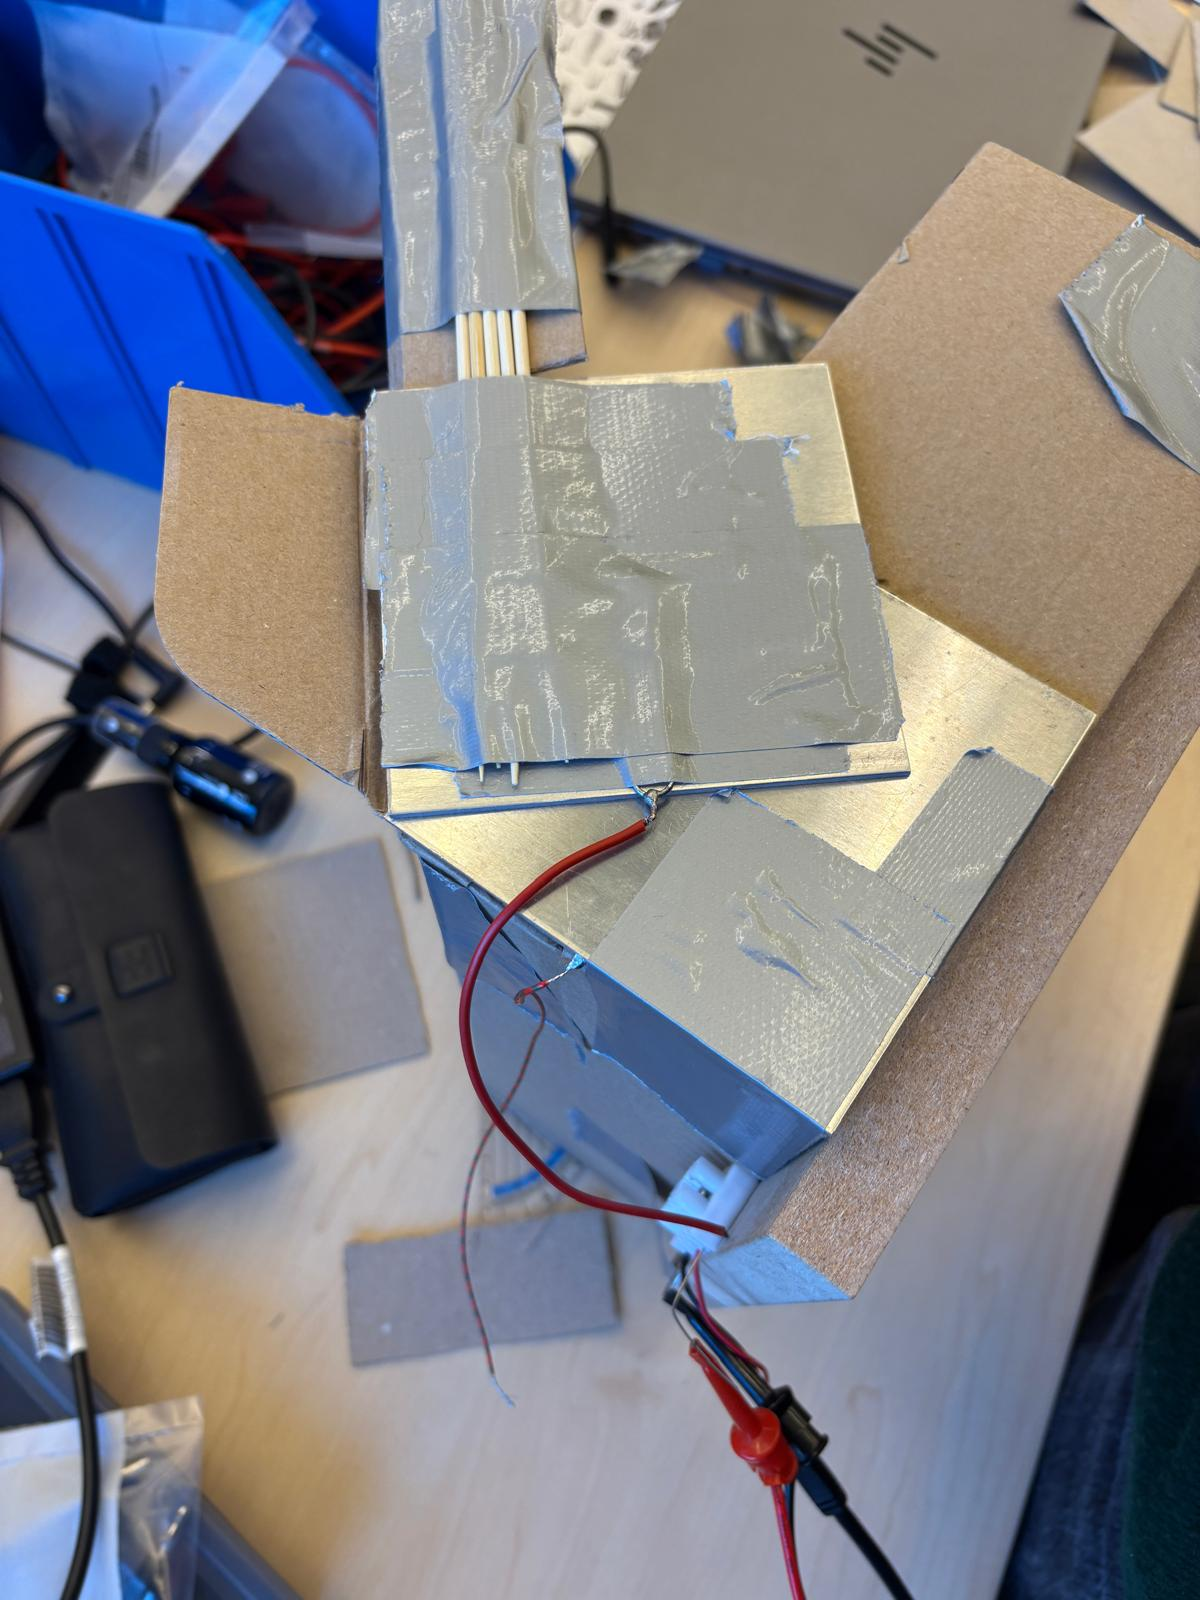

In [11]:


def vlakkeplaat(length,width,spacing,epsilon_r): #2.
   
    return epsilon0*epsilon_r*length*width/spacing
    
def capacitance(Vout_peak, R, A, f):
    return  Vout_peak/(R*A*2*np.pi*f)
def opp(x):
    c=np.cos(x)*10
    e=np.sin(x)*10
    a=10-c
    d=10-e   
    b= d*np.tan(x)
    return 100-0.5*c*e-b*d*0.5-a*10
def vlakkeplaat(oppervlakte,spacing,epsilon_r): #2.
   
    return epsilon0*epsilon_r*oppervlakte/spacing
x_test = np.linspace(0,0.5*np.pi,1000)
oppervlak = opp(x_test)/10000
plt.plot(x_test,(vlakkeplaat(oppervlak,0.8e-2,2.5)),'.',label="theoretisch verband")
plt.xlabel("hoek [radialen]")
plt.ylabel("capaciteit [F]")
plt.title("theoretisch verband tussen de hoek van de platen en de capaciteit")
plt.legend()
plt.show()
display(Image("tekening_opstelling.jpeg"))
display(Image("opstelling1.jpeg"))
display(Image("opstelling2.jpeg"))
display(Image("opstelling3.jpeg"))

## Leerdoel 2

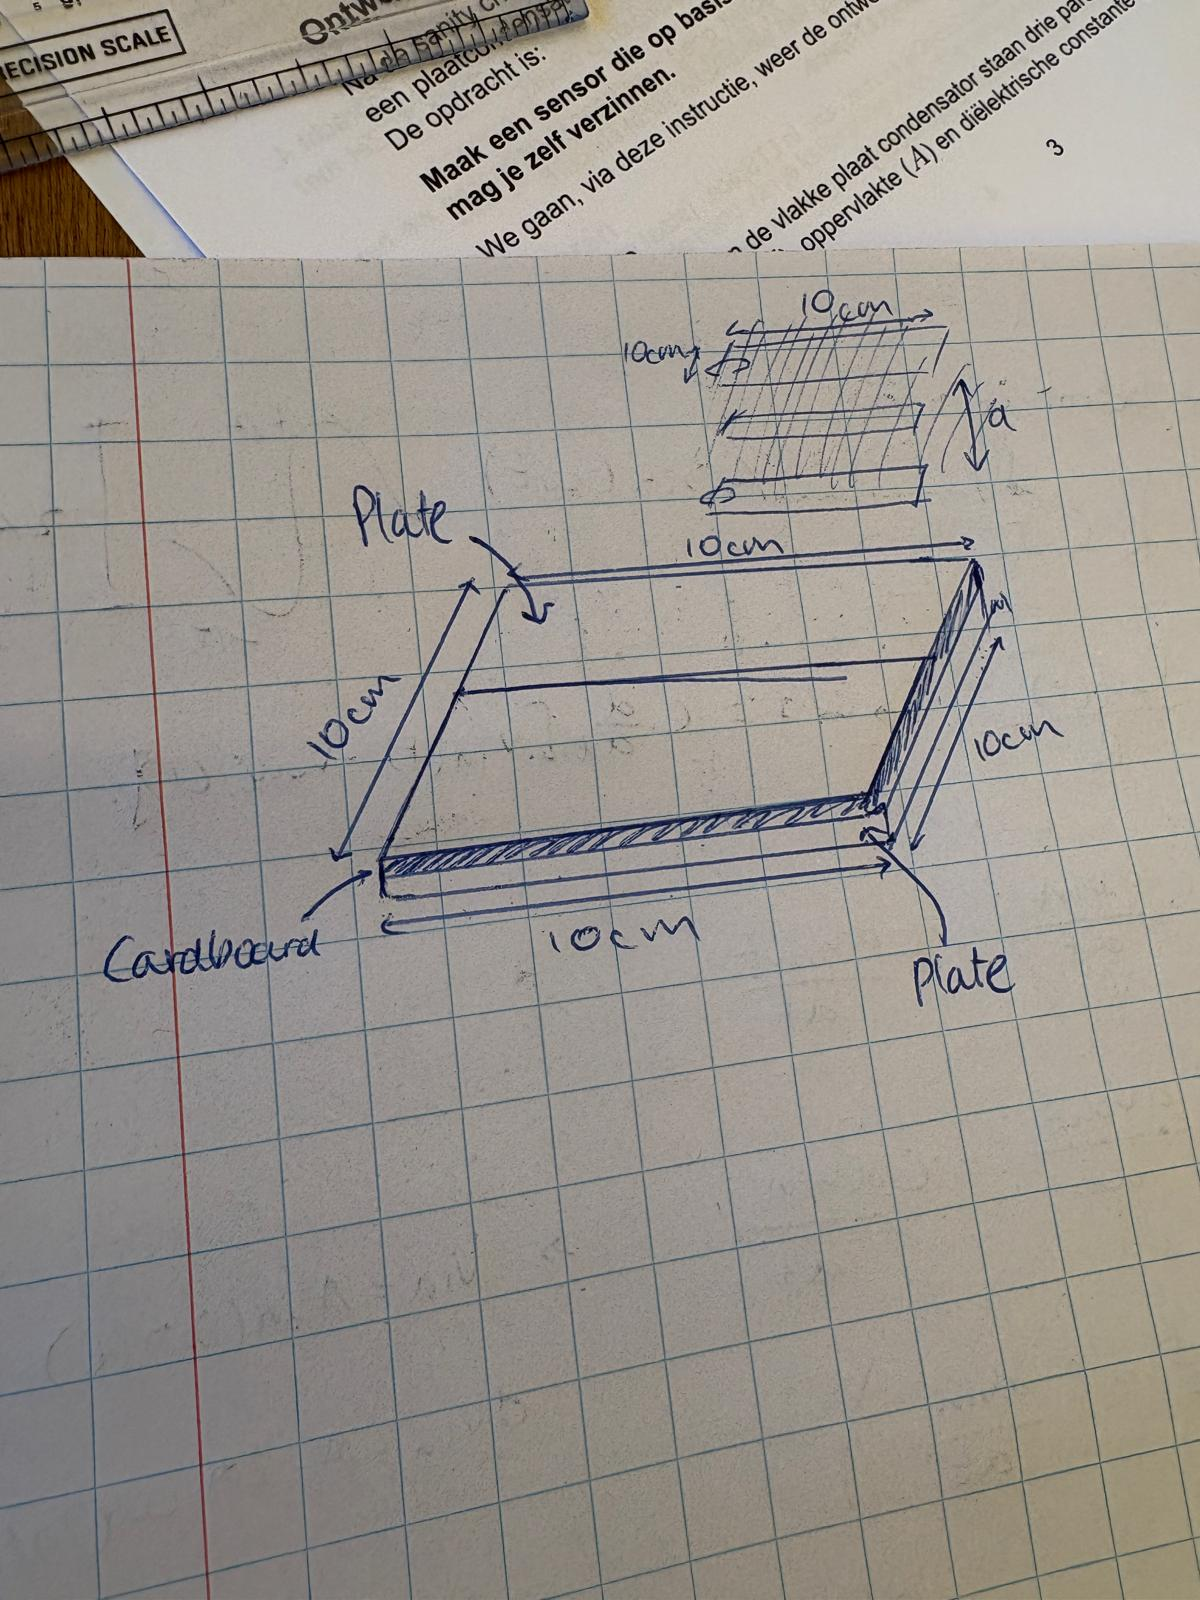

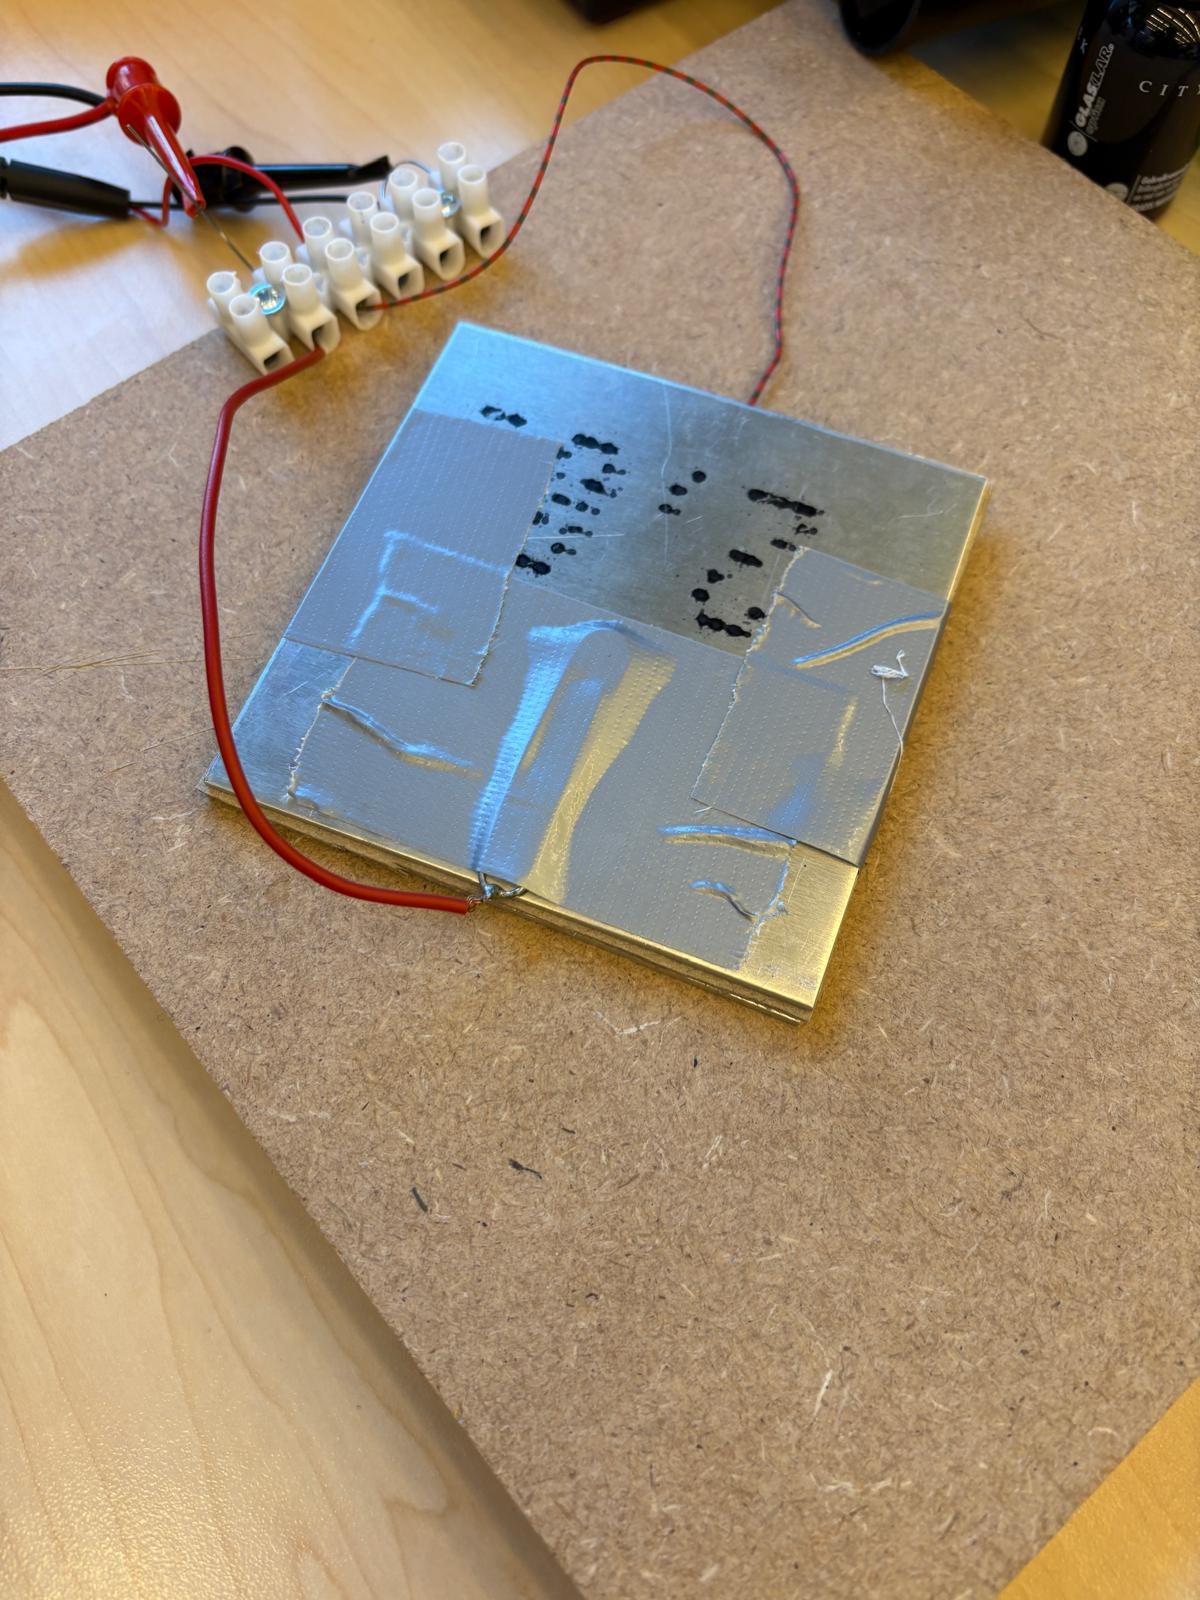

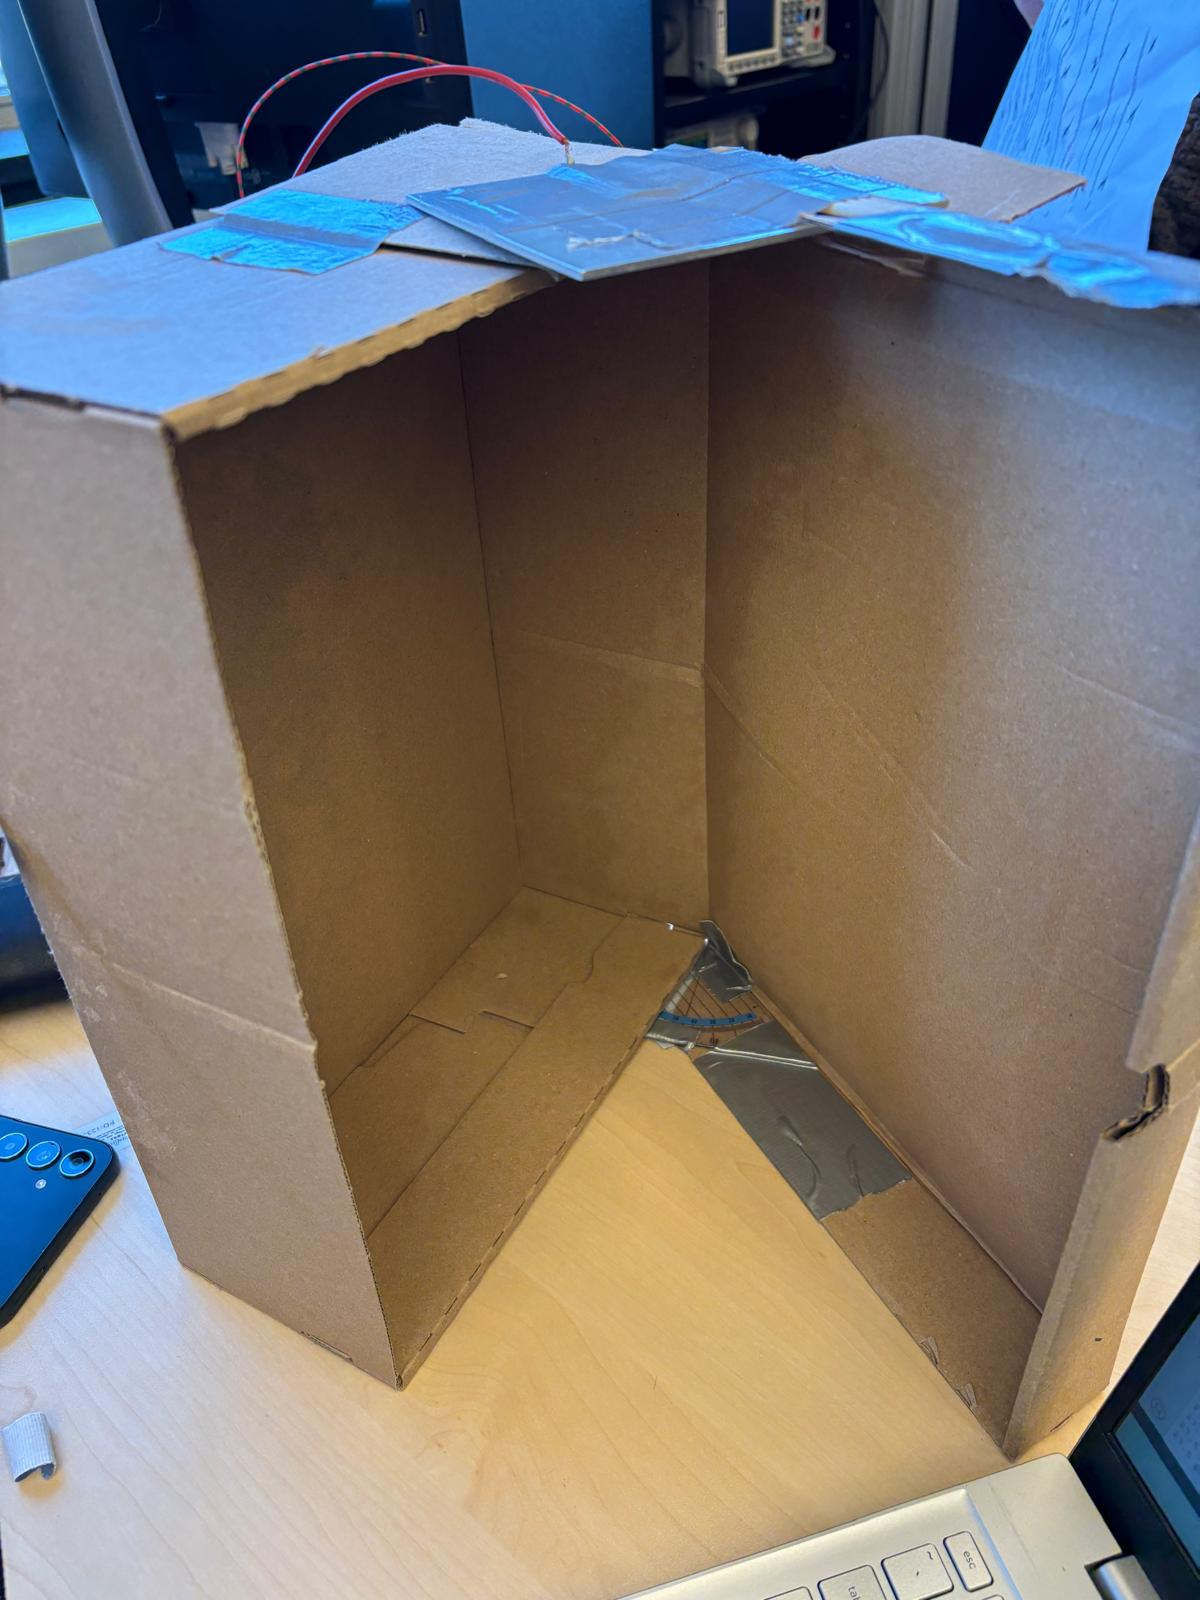

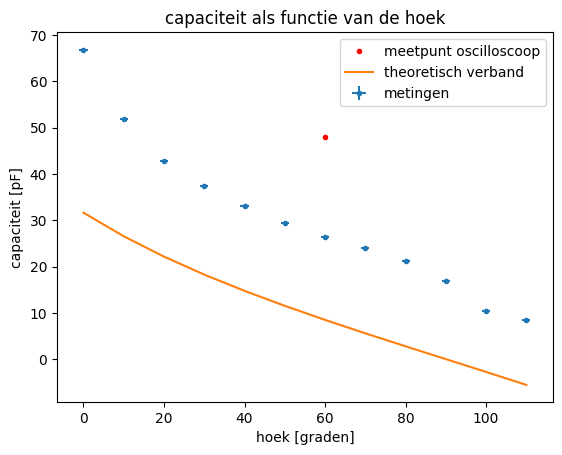

In [12]:

display(Image("schets_eerste.jpeg"))
display(Image("foto_eerste.jpeg"))
display(Image("opstelling1.jpeg"))
def vlakkeplaat(length,width,spacing,epsilon_r): #2.
   
    return epsilon0*epsilon_r*length*width/spacing
    
def capacitance(Vout_peak, R, A, f):
    return  Vout_peak/(R*A*2*np.pi*f)
graden = np.array([0,10,20,30,40,50,60,70,80,90,100,110])
radialen = graden/180*np.pi
Farad = np.array([66.8,51.8,42.8,37.3,33,29.5,26.3,23.9,21.2,16.8,10.3,8.5])

plt.errorbar(graden,Farad,0.2,1,'.',label="metingen")
osci = 48
def opp(x):
    c=np.cos(x)*10
    e=np.sin(x)*10
    a=10-c
    d=10-e   
    b= d*np.tan(x)
    return 100-0.5*c*e-b*d*0.5-a*10
opps = opp(radialen)/10000
def vlakkeplaat(oppervlakte,spacing,epsilon_r): #2.
   
    return epsilon0*epsilon_r*oppervlakte/spacing

x_test = np.linspace(0,110,1000)
plt.plot(60,osci,'r.',label='meetpunt oscilloscoop')
plt.plot(graden,(vlakkeplaat(opps,0.7e-2,2.5)/1e-12),label="theoretisch verband")
plt.xlabel('hoek [graden]')
plt.ylabel('capaciteit [pF]')
plt.title("capaciteit als functie van de hoek")
plt.legend()
plt.show()

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 20 |131.15 |
| gemiddelde capaciteit| 56 |281.15 |
| maximale capaciteit| 91 |458.01 |

## Leerdoel 3

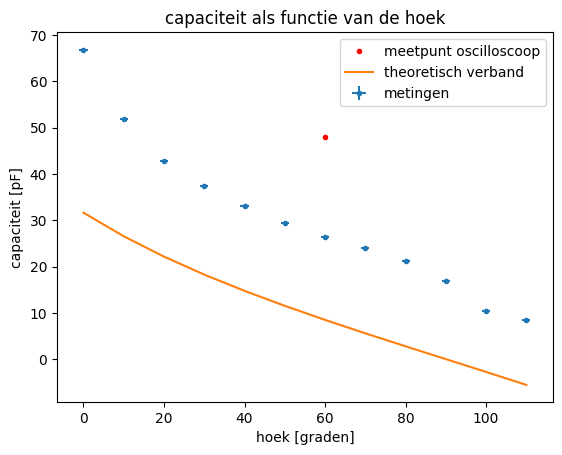

In [13]:


graden = np.array([0,10,20,30,40,50,60,70,80,90,100,110])
radialen = graden/180*np.pi
Farad = np.array([66.8,51.8,42.8,37.3,33,29.5,26.3,23.9,21.2,16.8,10.3,8.5])

plt.errorbar(graden,Farad,0.2,1,'.',label="metingen")
osci = 48
def opp(x):
    c=np.cos(x)*10
    e=np.sin(x)*10
    a=10-c
    d=10-e   
    b= d*np.tan(x)
    return 100-0.5*c*e-b*d*0.5-a*10
opps = opp(radialen)/10000
def vlakkeplaat(oppervlakte,spacing,epsilon_r): #2.
   
    return epsilon0*epsilon_r*oppervlakte/spacing

x_test = np.linspace(0,110,1000)
plt.plot(60,osci,'r.',label='meetpunt oscilloscoop')
plt.plot(graden,(vlakkeplaat(opps,0.7e-2,2.5)/1e-12),label="theoretisch verband")
plt.xlabel('hoek [graden]')
plt.ylabel('capaciteit [pF]')
plt.title("capaciteit als functie van de hoek")
plt.legend()
plt.show()


In conclusie, hadden wij in het theoretische model in opdracht 4 gemaakt om te vergelijken met de fysieke resultaat. Uiteidelijk met gebruik van dit theoretische model hebben wij de zelfde curve fit in onze echte data gebruikt. Qua data bij het meten met de arduino waren er duidelijke mooie trends. Elke keer wanneer de doos 10 graden verder werdt geschoven gaf de arduino een mooie dalende curve en wanneer de deur niet meer bewogen werd stabiliseerde de grafiek. Uiteindelijk was er een stevige concreet relatie tussen de hoek (graden) en capaciteit (pF), de correlatie was negatief. Met toename in de hoek kregen wij een afname in de capaciteit. Het theoretische model heeft ook dezelfde vorm als een lijn door de gemeten punten. Echter blijkt de de voorspelde curve niet overeen te komen met onze gemeten punten, dit kan meerdere oorzaken hebben. Voor het theoretische model hebben is aaangenomen dat de scharnier niet beweegt, dit is echter wel zo als de doos geopend wordt. Daarnaast wordt er ook van uitgegaan dat het elektrische veld aan de rand van de platen stopt en dat er geen edge effecten zijn. Ook varieert de afstand tussen de platen wanneer de doos geopend wordt. Dit allemaal draagt eraan bij dat de curve weliswaar dezelfde vorm heeft als de gemeten punten, maar niet op dezelfde plek is.